# Deep Learning for Malaria Diagnosis
This notebook is inspired by works of (Sivaramakrishnan Rajaraman  et al., 2018) and (Jason Brownlee, 2019). Acknowledge to NIH and Bangalor Hospital who make available this malaria dataset.

Malaria is an infectious disease caused by parasites that are transmitted to people through the bites of infected female Anopheles mosquitoes.

The Malaria burden with some key figures:
<font color='red'>
* An estimated 282 million cases in 2024
* An estimated 610 000 deaths in 2024
* The WHO African Region carries about 94% of cases and 95% of deaths; 75% of deaths in the region are children under 5
* Source: WHO, *World malaria report 2025* (2024 data)
  </font>

![MalariaBurd](https://github.com/habiboulaye/ai-labs/blob/master/malaria-diagnosis/doc-images/MalariaBurden.png?raw=1)

The malaria diagnosis is performed using blood test:
* Collect patient blood smear
* Microscopic visualisation of the parasite

![MalariaDiag](https://github.com/habiboulaye/ai-labs/blob/master/malaria-diagnosis/doc-images/MalariaDiag.png?raw=1)
  
Main issues related to traditional diagnosis:
<font color='#ed7d31'>
* resource-constrained regions
* time needed and delays
* diagnosis accuracy and cost
</font>

The objective of this notebook is to apply modern deep learning techniques to perform medical image analysis for malaria diagnosis.

*This notebook is inspired by works of (Sivaramakrishnan Rajaraman  et al., 2018), (Adrian Rosebrock, 2018) and (Jason Brownlee, 2019)*

### About this notebook: Model 4 (custom plain CNN)
**Formative 2, Group 14.** Binary classification of segmented red-blood-cell images: **Parasitized (1)** vs **Uninfected (0)**.

**Model 4** is a hand-built, VGG-style CNN with **no skip connections** (the group's other custom model is a ResNet). We start from a minimal baseline and change **one factor per experiment**, so every difference in the results has a single cause.

**Evaluation protocol:** experiments are compared on the **validation** set; the **test** set is used once, at the very end.

**Map:** Configuration → Populating namespaces → Prepare DataSet → Model 4 design → Training & evaluation tooling → Experiments → Results

**How to run:** Runtime → Run all (GPU + the shared Drive folder needed). Training cells take the longest. Everything is saved to Drive, so the Results cells can be re-run without retraining.


## Configuration
Mount Google Drive (it holds the shared split and our outputs) and check that a GPU is available.


In [ ]:
#Mount the local drive project_forder
from google.colab import drive
drive.mount('/content/drive/')
!ls "/content/drive/MyDrive/ml-formative-2/"   # the drive shared folder

Mounted at /content/drive/
model4	split.json


In [ ]:
# Use GPU: Please check if the outpout is '/device:GPU:0'
import tensorflow as tf
print(tf.__version__)
tf.test.gpu_device_name()
#from tensorflow.python.client import device_lib
#device_lib.list_local_devices()

2.21.0


'/device:GPU:0'

## Populating namespaces
All imports live here, once. The first block is from the starter notebook; the second block is added for Model 4.


In [ ]:
# Importing basic libraries
import os
import random
import shutil
from matplotlib import pyplot
from matplotlib.image import imread
%matplotlib inline

# Importing the Keras libraries and packages
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Convolution2D as Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense

# Additional imports for Model
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split
from tensorboard.plugins.hparams import api as hp
from tensorflow import keras
from tensorflow.keras import layers, regularizers

### Paths and settings
Every constant in one place: seed, image size, batch size, epoch budget and folders. All runs share the same budget, so comparisons are fair.

In [ ]:
# Define the useful paths for data accessibility
ai_project = '.' #"/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis"
cell_images_dir = os.path.join(ai_project,'cell_images')
training_path = os.path.join(ai_project,'train')
testing_path = os.path.join(ai_project,'test')

# Model 4 configuration
SEED = 42
IMG_SIZE, BATCH_SIZE = (128, 128), 32
MAX_EPOCHS, PATIENCE = 25, 5          # identical budget for every run = fair comparison
AUTOTUNE = tf.data.AUTOTUNE
CLASS_TO_LABEL = {"Uninfected": 0, "Parasitized": 1}   # 1 = Parasitized (positive class)

DATA_DIR = Path(cell_images_dir)                              # where the images are unzipped
SHARED_DIR = Path("/content/drive/MyDrive/ml-formative-2")    # group-shared folder
SPLIT_PATH = SHARED_DIR / "split.json"                        # one split for the whole group

ROOT = SHARED_DIR / "model4"                                  # Model 4 outputs
LOG_DIR, MODEL_DIR = ROOT / "logs", ROOT / "models"
RESULTS_CSV = ROOT / "results.csv"

keras.utils.set_random_seed(SEED)     # reproducible weight init and shuffling

## Prepare DataSet

### *Download* DataSet
Get the NIH malaria cell images. The download is skipped if the images are already on disk.


In [ ]:
# Download the data in the allocated google cloud-server. If already down, turn downloadData=False
downloadData = not os.path.exists(cell_images_dir)   # skip the download if the data is already here
if downloadData == True:
  indrive = False
  if indrive == True:
    !wget https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip -P "/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis"
    !unzip "/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis/cell_images.zip" -d "/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis/"
    !ls "/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis"
  else: #incloud google server
    !rm -rf cell_images.*
    !wget https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip
    !unzip cell_images.zip >/dev/null 2>&1
    !ls

--2026-10-06 19:27:59--  https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip
Resolving data.lhncbc.nlm.nih.gov (data.lhncbc.nlm.nih.gov)... 3.173.161.58, 3.173.161.10, 3.173.161.53, ...
Connecting to data.lhncbc.nlm.nih.gov (data.lhncbc.nlm.nih.gov)|3.173.161.58|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 353452851 (337M) [application/zip]
Saving to: ‘cell_images.zip’

cell_images.zip     100%[===================>] 337.08M   146MB/s    in 2.3s    

2026-10-06 19:28:02 (146 MB/s) - ‘cell_images.zip’ saved [353452851/353452851]

cell_images  cell_images.zip  drive  sample_data


### Verify the dataset
Check the class folders and image counts. Counting only `*.png` avoids the stray `Thumbs.db` files shipped in the archive.

In [ ]:
# Verify dataset structure and per-class image counts
root = DATA_DIR
print("Contents:", sorted(p.name for p in root.iterdir()))

for cls in ("Parasitized", "Uninfected"):
    n = len(list((root / cls).glob("*.png")))
    print(f"{cls:12s} {n}")

Contents: ['Parasitized', 'Uninfected']
Parasitized  13779
Uninfected   13779


### Shared stratified split (80 / 10 / 10)
The **whole group uses one `split.json`**, so every model is trained and tested on identical images and results are comparable. It is created once (stratified, seed 42) and then only loaded.
- **Train (80%)**: the model learns from these.
- **Validation (10%)**: used to compare experiments.
- **Test (10%)**: used once, at the very end.

The assertion at the bottom confirms the three subsets are disjoint (no leakage).

In [ ]:
# Build (first time only) or load the shared split
def build_split() -> dict:
    """Stratified 80/10/10 split of relative image paths."""
    paths, labels = [], []
    for cls, label in CLASS_TO_LABEL.items():
        files = sorted((DATA_DIR / cls).glob("*.png"))  # sorted -> deterministic
        paths += [f"{cls}/{f.name}" for f in files]
        labels += [label] * len(files)

    # 80% train, then split the remaining 20% evenly into val and test
    p_train, p_rest, y_train, y_rest = train_test_split(
        paths, labels, test_size=0.2, stratify=labels, random_state=SEED)
    p_val, p_test, y_val, y_test = train_test_split(
        p_rest, y_rest, test_size=0.5, stratify=y_rest, random_state=SEED)

    return {
        "train": {"paths": p_train, "labels": y_train},
        "val": {"paths": p_val, "labels": y_val},
        "test": {"paths": p_test, "labels": y_test},
    }


SHARED_DIR.mkdir(parents=True, exist_ok=True)
if SPLIT_PATH.exists():
    print("Loading existing split:", SPLIT_PATH)
else:
    SPLIT_PATH.write_text(json.dumps(build_split()))
    print("Created new split:", SPLIT_PATH)

split = json.loads(SPLIT_PATH.read_text())
for name, d in split.items():
    n_pos = sum(d["labels"])
    print(f"{name:5s} n={len(d['labels']):6d}  parasitized={n_pos} ({n_pos / len(d['labels']):.1%})")

# No image may appear in more than one subset
sets = [set(split[k]["paths"]) for k in ("train", "val", "test")]
assert not (sets[0] & sets[1] or sets[0] & sets[2] or sets[1] & sets[2]), "Split leakage!"

Loading existing split: /content/drive/MyDrive/ml-formative-2/split.json
train n= 22046  parasitized=11023 (50.0%)
val   n=  2756  parasitized=1378 (50.0%)
test  n=  2756  parasitized=1378 (50.0%)


### Visual inspection
Eight random cells per class, titled with raw width×height. Raw images **vary in size**, which is why everything is resized to 128×128 in the pipeline. Parasitized cells show dark stained parasite regions; uninfected cells look uniformly pale.

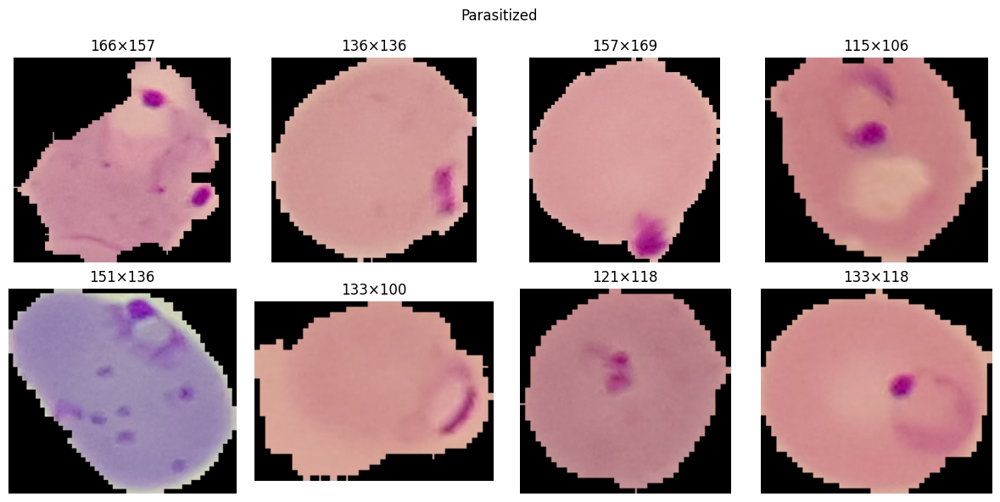

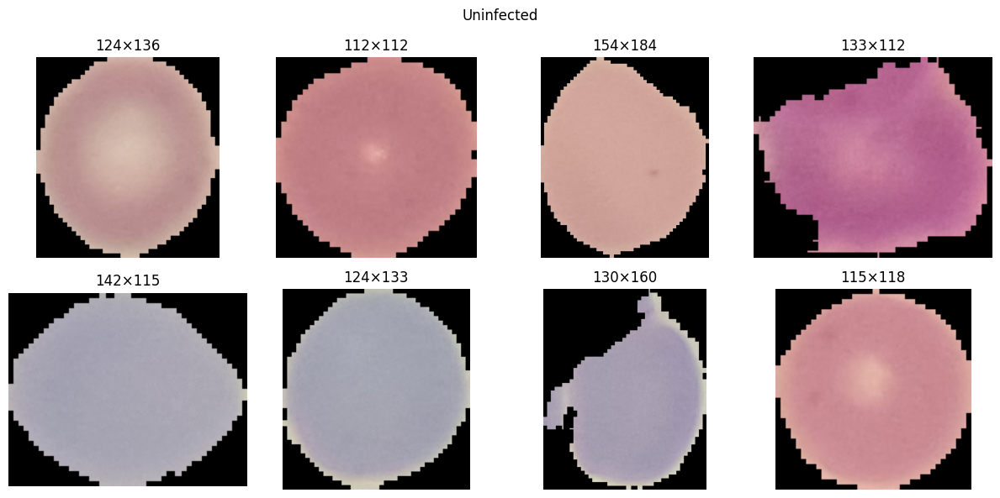

In [ ]:
def show_samples(cls: str, n: int = 8, seed: int = SEED) -> None:
    """Plot n random images of a class, titled with raw width×height."""
    files = sorted((DATA_DIR / cls).glob("*.png"))      # sorted -> same sample on every machine
    files = random.Random(seed).sample(files, n)
    fig, axes = plt.subplots(2, n // 2, figsize=(12, 6))
    for ax, f in zip(axes.ravel(), files):
        img = imread(f)
        ax.imshow(img)
        ax.set_title(f"{img.shape[1]}×{img.shape[0]}")
        ax.axis("off")
    fig.suptitle(cls)
    plt.tight_layout()
    plt.show()


show_samples("Parasitized")
show_samples("Uninfected")

### Input pipeline (`tf.data`)
Decode → resize to 128×128 → scale to [0, 1] → batch → prefetch.
- **No augmentation by default.** It is an *experiment variable* (Experiment 3), so the baseline stays clean. With `augment=True`, random flips and rotations (`AUGMENTER`: horizontal + vertical flips, rotation up to ±0.1 of a full turn = **±36°**) are applied to the **training set only**.
- Val and test are never shuffled, which keeps prediction order stable for error analysis and Grad-CAM.

In [ ]:
# Cells have no canonical orientation, so flips/rotations are label-preserving.
# Rotation corners are filled with black, matching the dataset's background.
# RandomRotation(0.1) = fraction of a full turn -> uniform in ±0.1 x 360° = ±36°.
AUGMENTER = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.1, fill_mode="constant", fill_value=0.0),
], name="augmenter")


def make_dataset(name: str, shuffle: bool = False, augment: bool = False) -> tf.data.Dataset:
    """tf.data pipeline: decode -> resize -> [0,1]. Augmentation is off unless an experiment asks for it."""
    paths = [str(DATA_DIR / p) for p in split[name]["paths"]]
    labels = np.array(split[name]["labels"], dtype="float32")

    def load(path, label):
        img = tf.io.decode_png(tf.io.read_file(path), channels=3)
        img = tf.image.resize(img, IMG_SIZE) / 255.0  # float32 in [0, 1]
        return img, label

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:  # full shuffle of filenames is cheap (strings only)
        ds = ds.shuffle(len(paths), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(load, num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE)
    if augment:  # applied to whole batches, training set only
        ds = ds.map(lambda x, y: (AUGMENTER(x, training=True), y), num_parallel_calls=AUTOTUNE)
    return ds.prefetch(AUTOTUNE)


train_ds = make_dataset("train", shuffle=True)
val_ds = make_dataset("val")
test_ds = make_dataset("test")  # never shuffled: keeps order for error analysis and Grad-CAM; used only at the end

# Sanity check one batch
x, y = next(iter(train_ds))
print(x.shape, x.dtype, float(tf.reduce_min(x)), float(tf.reduce_max(x)), y[:8].numpy())

(32, 128, 128, 3) <dtype: 'float32'> 0.0 0.9466874599456787 [1. 0. 1. 1. 0. 0. 1. 0.]


## Model 4 design

### Baseline CNN Model (template)
Define a basic ConvNet defined with ConvLayer: Conv2D => MaxPooling2D followed by Flatten => Dense => Dense(output)

![ConvNet](https://github.com/habiboulaye/ai-labs/blob/master/malaria-diagnosis/doc-images/ConvNet.png?raw=1)

**Model 4 extends this baseline with one configurable builder**, so each experiment differs from the previous one by **a single argument**:

| Knob | Values | Purpose |
|---|---|---|
| `convs_per_block` | 1, 2 | depth of each block |
| `batch_norm` | bool | Conv → BN → ReLU (conv bias dropped, it is redundant before BN) |
| `head` | `flatten` \| `gap` | Flatten keeps the spatial layout, GAP cuts parameters |
| `dropout` | 0–1 | regularisation in the head |
| `l2` | ≥ 0 | weight decay on conv and dense kernels |

**Architecture:** 4 blocks (32 → 64 → 128 → 256 filters), each `[Conv3×3 → (BN) → ReLU] × n → MaxPool2×2`, then `Dense(128)` and a 1-unit sigmoid giving P(Parasitized). He initialisation suits ReLU. Layers are named `block{b}_conv{i}` / `block{b}_relu{i}` so Grad-CAM can find the last convolutional feature map.

In [ ]:
def build_plain_cnn(
    input_shape=(*IMG_SIZE, 3),
    filters=(32, 64, 128, 256),
    convs_per_block=1,       # 1 = baseline, 2 = deeper blocks
    batch_norm=False,
    head="flatten",          # "flatten" | "gap"
    dense_units=128,
    dropout=0.0,             # applied in the head only
    l2=0.0,                  # weight decay on conv + dense kernels
    name="plain_cnn",
) -> keras.Model:
    """VGG-style plain CNN: [Conv3x3 -> (BN) -> ReLU] x n -> MaxPool, repeated; no skip connections."""
    reg = regularizers.l2(l2) if l2 > 0 else None
    model = keras.Sequential(name=name)
    model.add(keras.Input(shape=input_shape))

    for b, f in enumerate(filters, start=1):
        for i in range(1, convs_per_block + 1):
            model.add(layers.Conv2D(
                f, 3, padding="same", kernel_initializer="he_normal",
                kernel_regularizer=reg,
                use_bias=not batch_norm,          # bias is redundant before BN
                name=f"block{b}_conv{i}"))
            if batch_norm:
                model.add(layers.BatchNormalization(name=f"block{b}_bn{i}"))
            model.add(layers.ReLU(name=f"block{b}_relu{i}"))
        model.add(layers.MaxPooling2D(2, name=f"block{b}_pool"))

    # Classifier head
    if head == "gap":
        model.add(layers.GlobalAveragePooling2D(name="gap"))
    elif head == "flatten":
        model.add(layers.Flatten(name="flatten"))
    else:
        raise ValueError(f"Unknown head: {head!r}")

    model.add(layers.Dense(dense_units, activation="relu",
                           kernel_initializer="he_normal",
                           kernel_regularizer=reg, name="fc"))
    if dropout > 0:
        model.add(layers.Dropout(dropout, name="dropout"))
    model.add(layers.Dense(1, activation="sigmoid", name="output"))  # P(Parasitized)
    return model


def last_conv_name(model: keras.Model) -> str:
    """Grad-CAM target: the activated feature map of the last conv (pre-pool, 16x16)."""
    conv = [l.name for l in model.layers if isinstance(l, layers.Conv2D)][-1]
    return conv.replace("_conv", "_relu")

### Verify the builder
Before training anything, check that the model matches the design: parameter count, output shape and range, the Grad-CAM layer, and that the deeper variant also builds.

In [ ]:
model = build_plain_cnn()
model.summary()

# 1) Parameter count must match the design table
assert model.count_params() == 2_485_825, model.count_params()

# 2) Output shape and range on a dummy batch
out = model(tf.random.uniform((4, 128, 128, 3)))
assert out.shape == (4, 1) and bool(tf.reduce_all((out > 0) & (out < 1)))

# 3) Grad-CAM target exists and is 16x16 spatial
target = model.get_layer(last_conv_name(model))
print("Grad-CAM layer:", target.name, target.output.shape)

# 4) Deeper variant builds (target-shape check)
deep = build_plain_cnn(convs_per_block=2, batch_norm=True, head="gap", dropout=0.5)
print(f"Deep variant params: {deep.count_params():,}")

Model: "plain_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ block1_conv1 (Conv2D)           │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_relu1 (ReLU)             │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_relu1 (ReLU)             │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_relu1 (ReLU)             │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_relu1 (ReLU)             │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc (Dense)                      │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,485,825 (9.48 MB)

 Trainable params: 2,485,825 (9.48 MB)

 Non-trainable params: 0 (0.00 B)

Grad-CAM layer: block4_relu1 (None, 16, 16, 256)
Deep variant params: 1,208,161


## Training and evaluation tooling

### Compile and evaluate
- `compile_model`: one shared compile step (Adam, binary cross-entropy, same metrics), so runs differ **only** in what we change on purpose.
- `evaluate_model`: one pass over a dataset collects labels and probabilities together (so they stay aligned), then computes accuracy, precision, **sensitivity** (recall of Parasitized, the clinically critical number: a missed infection is the costly error), specificity, F1, AUC and the confusion matrix.
- AUC comes from **scikit-learn** (exact). Keras' streaming `val_auc` is an approximation and differs slightly, so we report only the sklearn value.

In [ ]:
def compile_model(model: keras.Model, lr: float = 1e-3) -> keras.Model:
    """Shared compile step so every experiment uses identical metrics."""
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=[
            keras.metrics.BinaryAccuracy(name="accuracy"),
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),   # recall of class 1 = sensitivity
            keras.metrics.AUC(name="auc"),
        ],
    )
    return model

In [ ]:
def evaluate_model(model: keras.Model, ds, threshold: float = 0.5) -> dict:
    """Return the full metric set (label 1 = Parasitized).

    Labels and predictions are collected in a single pass so they stay aligned
    even if the dataset reshuffles. Use val_ds during development; test_ds only once, at the end.
    """
    y_true, y_prob = [], []
    for x, y in ds:
        y_prob.append(model.predict_on_batch(x).ravel())
        y_true.append(y.numpy().ravel())
    y_true, y_prob = np.concatenate(y_true), np.concatenate(y_prob)
    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    precision = tp / (tp + fp)
    sensitivity = tp / (tp + fn)          # recall of Parasitized
    return {
        "accuracy": (tp + tn) / len(y_true),
        "precision": precision,
        "sensitivity": sensitivity,
        "specificity": tn / (tn + fp),
        "f1": 2 * precision * sensitivity / (precision + sensitivity),
        "auc": roc_auc_score(y_true, y_prob),
        "confusion": np.array([[tn, fp], [fn, tp]]),
        "y_true": y_true,
        "y_prob": y_prob,   # kept for ROC curve and error analysis later
    }

### Experiment engine
`run_experiment` trains one configuration end to end and records everything:
- **Callbacks:** TensorBoard logs; checkpoint of the best `val_loss`; early stopping (patience 5, best weights restored).
- **Outputs:** the best model, TensorBoard HParams, `history.json`, and **one row in `results.csv`**. Re-running an experiment *replaces* its row, so there are no duplicates.
- **Required TensorBoard fields** (per the brief): architecture, learning rate, optimizer, batch size, epochs, augmentation, dropout/L2, and `strategy` (`from_scratch`: no pretrained weights, so nothing is frozen/unfrozen), plus train/val curves and final precision / recall (sensitivity) / F1 / AUC.
- `augmentation` is only a **label** for the logs. To actually augment, pass a `train_ds` built with `make_dataset(..., augment=True)`.

In [ ]:
SCALAR_METRICS = ("accuracy", "precision", "sensitivity", "specificity", "f1", "auc")


def log_result(row: dict) -> None:
    """Upsert one row into results.csv (re-running an experiment replaces its row)."""
    df = pd.read_csv(RESULTS_CSV) if RESULTS_CSV.exists() else pd.DataFrame()
    if not df.empty:
        df = df[df["run"] != row["run"]]
    pd.concat([df, pd.DataFrame([row])], ignore_index=True).to_csv(RESULTS_CSV, index=False)


def run_experiment(name, change, model_kwargs, train_ds, val_ds,
                   lr=1e-3, augmentation="none", seed=SEED, max_epochs=MAX_EPOCHS) -> dict:
    """Train one experiment end to end.

    name          e.g. 'plain_cnn_exp_01_baseline' (TensorBoard run name)
    change        one-line description of what differs from the previous config
    model_kwargs  arguments for build_plain_cnn
    augmentation  label only; the augmentation itself comes from train_ds
    """
    keras.utils.set_random_seed(seed) # identical init across runs

    shutil.rmtree(LOG_DIR / name, ignore_errors=True)  # a re-run must never mix with old event files

    for d in (LOG_DIR / name, MODEL_DIR):
        d.mkdir(parents=True, exist_ok=True)
    model_path = MODEL_DIR / f"{name}.keras"

    model = compile_model(build_plain_cnn(name=name, **model_kwargs), lr=lr)
    history = model.fit(
        train_ds, validation_data=val_ds, epochs=max_epochs,
        callbacks=[
            keras.callbacks.TensorBoard(log_dir=str(LOG_DIR / name)),
            keras.callbacks.ModelCheckpoint(model_path, monitor="val_loss", save_best_only=True),
            keras.callbacks.EarlyStopping(monitor="val_loss", patience=PATIENCE,
                                          restore_best_weights=True),
        ],
    )

    # Metrics of the best (restored) weights on the VALIDATION set
    res = evaluate_model(model, val_ds)
    scalars = {k: float(res[k]) for k in SCALAR_METRICS}
    epochs_run = len(history.history["loss"])
    best_epoch = int(np.argmin(history.history["val_loss"])) + 1   # 1-based, matches the epoch log

    # Required hparams -> TensorBoard HParams table
    hparams = {
        "architecture": (f"plain_{len(model_kwargs.get('filters', (0,)*4))}blk"
                         f"_c{model_kwargs.get('convs_per_block', 1)}"
                         f"_{'bn' if model_kwargs.get('batch_norm') else 'nobn'}"
                         f"_{model_kwargs.get('head', 'flatten')}"),
        "learning_rate": lr, "optimizer": "adam", "batch_size": BATCH_SIZE,
        "max_epochs": max_epochs, "epochs_run": epochs_run,
        "augmentation": augmentation,
        "strategy": "from_scratch",   # required field: transfer-learning strategy (none here)
        "dropout": float(model_kwargs.get("dropout", 0.0)),
        "l2": float(model_kwargs.get("l2", 0.0)),
    }
    writer = tf.summary.create_file_writer(str(LOG_DIR / name))
    with writer.as_default():
      hp.hparams(hparams, trial_id=name)
      # "recall" is logged as an alias of sensitivity because the brief asks for both names
      for k, v in {**scalars, "recall": scalars["sensitivity"]}.items():
        tf.summary.scalar(f"final_{k}", v, step=1)
    writer.close()

    # One row per run -> comparison table
    row = {"run": name, "change": change, **hparams, "best_epoch": best_epoch,
           "params": model.count_params(), "val_loss": float(min(history.history["val_loss"])), **scalars}
    log_result(row)
    (LOG_DIR / name / "history.json").write_text(json.dumps(history.history))
    return {**row, "model": model, "history": history, "eval": res}


def summarize(result: dict) -> pd.Series:
    """Compact view of a run (hides the model/history objects)."""
    return pd.Series({k: v for k, v in result.items() if k not in ("model", "history", "eval")})

### Learning curves
Train vs validation loss and accuracy per epoch, with the best epoch marked. A widening gap, with val loss rising while train loss keeps falling, signals **overfitting**.

In [ ]:
def plot_curves(result: dict) -> None:
    """Plot train/val loss and accuracy; mark the best epoch."""
    h = result["history"].history
    best = result["best_epoch"]  # 1-based, matches the epoch log
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for ax, key, title in zip(axes, ("loss", "accuracy"), ("Loss", "Accuracy")):
        ax.plot(range(1, len(h[key]) + 1), h[key], label="train")
        ax.plot(range(1, len(h[key]) + 1), h[f"val_{key}"], label="val")
        ax.axvline(best, ls="--", c="gray", label=f"best epoch ({best})")
        ax.set(title=title, xlabel="Epoch")
        ax.legend()
    fig.suptitle(result["run"])
    plt.tight_layout()
    plt.show()

### One-off cleanup
Removes the leftover artifacts of the 1-epoch plumbing test (`plain_cnn_smoke_test`) from Drive. Safe to re-run; it does nothing if they are already gone.

In [ ]:
shutil.rmtree(LOG_DIR / "plain_cnn_smoke_test", ignore_errors=True)
(MODEL_DIR / "plain_cnn_smoke_test.keras").unlink(missing_ok=True)

## Experiments
Every run shares: Adam (lr 1e-3), batch 32, max 25 epochs, early stopping (patience 5 on `val_loss`), seed 42, validation set only. Each section follows **Hypothesis → Change → Result → Decision**.

### TensorBoard HParams dashboard (one-time setup)
Declares which hyperparameters and final metrics the **HParams** tab shows, so every run appears as one comparable row (useful for the required TensorBoard screenshots). Safe to re-run.

In [ ]:
# Register the HParams columns and final metrics shown in TensorBoard's HParams tab
LOG_DIR.mkdir(parents=True, exist_ok=True)
with tf.summary.create_file_writer(str(LOG_DIR)).as_default():
    hp.hparams_config(
        hparams=[hp.HParam(k) for k in (
            "architecture", "learning_rate", "optimizer", "batch_size", "max_epochs",
            "epochs_run", "augmentation", "dropout", "l2", "strategy")],
        metrics=[hp.Metric(f"final_{k}") for k in (*SCALAR_METRICS, "recall")],
    )

### Experiment 1: Baseline
**Hypothesis:** a minimal plain CNN already separates the classes well (the task is visually easy), but with no regularisation it will overfit.
**Change:** none. 1 conv per block, no BatchNorm, Flatten head, no dropout / L2 / augmentation (2,485,825 parameters).

In [ ]:
# Experiment 1: baseline, all knobs at their minimal setting
result_01 = run_experiment(
    name="plain_cnn_exp_01_baseline",
    change="baseline: 1 conv/block, no BN, Flatten head, no dropout/L2/augmentation",
    model_kwargs=dict(
        convs_per_block=1,
        batch_norm=False,
        head="flatten",
        dropout=0.0,
        l2=0.0,
    ),
    train_ds=train_ds,
    val_ds=val_ds,
    lr=1e-3,
    augmentation="none",
    seed=42,
)
summarize(result_01)

Epoch 1/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 40s 49ms/step - accuracy: 0.8299 - auc: 0.9189 - loss: 0.3836 - precision: 0.8465 - recall: 0.8060 - val_accuracy: 0.9485 - val_auc: 0.9845 - val_loss: 0.1544 - val_precision: 0.9783 - val_recall: 0.9173
Epoch 2/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 23s 33ms/step - accuracy: 0.9556 - auc: 0.9862 - loss: 0.1384 - precision: 0.9694 - recall: 0.9409 - val_accuracy: 0.9579 - val_auc: 0.9888 - val_loss: 0.1268 - val_precision: 0.9674 - val_recall: 0.9478
Epoch 3/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 25s 35ms/step - accuracy: 0.9599 - auc: 0.9896 - loss: 0.1184 - precision: 0.9708 - recall: 0.9482 - val_accuracy: 0.9601 - val_auc: 0.9908 - val_loss: 0.1242 - val_precision: 0.9789 - val_recall: 0.9405
Epoch 4/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 41s 35ms/step - accuracy: 0.9639 - auc: 0.9920 - loss: 0.1052 - precision: 0.9743 - recall: 0.9530 - val_accuracy: 0.9565 - val_auc: 0.9912 - val_loss: 0.1188 - val_precision: 0.9474 - val_recall: 0.9666
Epoch 5/25
689/689 ━━━━━

,0
run,plain_cnn_exp_01_baseline
change,"baseline: 1 conv/block, no BN, Flatten head, n..."
architecture,plain_4blk_c1_nobn_flatten
learning_rate,0.001
optimizer,adam
batch_size,32
max_epochs,25
epochs_run,9
augmentation,none
strategy,from_scratch


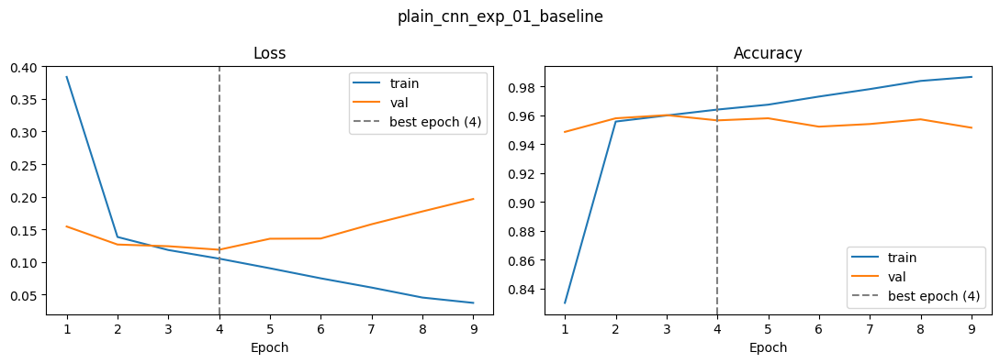

In [ ]:
plot_curves(result_01)

**Result:** early stopped at epoch 9, best epoch 4. Validation: accuracy **0.9565**, precision 0.9474, sensitivity 0.9666, specificity 0.9463, F1 0.9569, AUC 0.9918, val_loss 0.1188. At the best epoch train loss is 0.105 vs val 0.119; at the last epoch train falls to 0.037 while val rises to 0.197.
**Decision:** the baseline **overfits after about 4 epochs**, so the next experiments target generalisation. BatchNorm comes first because it is a single, cheap change.

### Experiment 2: BatchNorm
**Hypothesis:** BatchNorm stabilises and speeds up training and has a mild regularising effect, lowering val loss.
**Change (only this):** `batch_norm=True`, i.e. Conv → BN → ReLU with no conv bias.

Epoch 1/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 35s 42ms/step - accuracy: 0.8809 - auc: 0.9376 - loss: 0.4017 - precision: 0.8992 - recall: 0.8580 - val_accuracy: 0.9307 - val_auc: 0.9855 - val_loss: 0.2214 - val_precision: 0.8959 - val_recall: 0.9746
Epoch 2/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 24s 35ms/step - accuracy: 0.9527 - auc: 0.9854 - loss: 0.1432 - precision: 0.9674 - recall: 0.9370 - val_accuracy: 0.9550 - val_auc: 0.9899 - val_loss: 0.1249 - val_precision: 0.9693 - val_recall: 0.9398
Epoch 3/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 41s 35ms/step - accuracy: 0.9579 - auc: 0.9886 - loss: 0.1250 - precision: 0.9695 - recall: 0.9455 - val_accuracy: 0.9456 - val_auc: 0.9891 - val_loss: 0.1459 - val_precision: 0.9812 - val_recall: 0.9086
Epoch 4/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 29s 42ms/step - accuracy: 0.9607 - auc: 0.9897 - loss: 0.1176 - precision: 0.9703 - recall: 0.9506 - val_accuracy: 0.9528 - val_auc: 0.9887 - val_loss: 0.1394 - val_precision: 0.9522 - val_recall: 0.9536
Epoch 5/25
689/689 ━━━━━

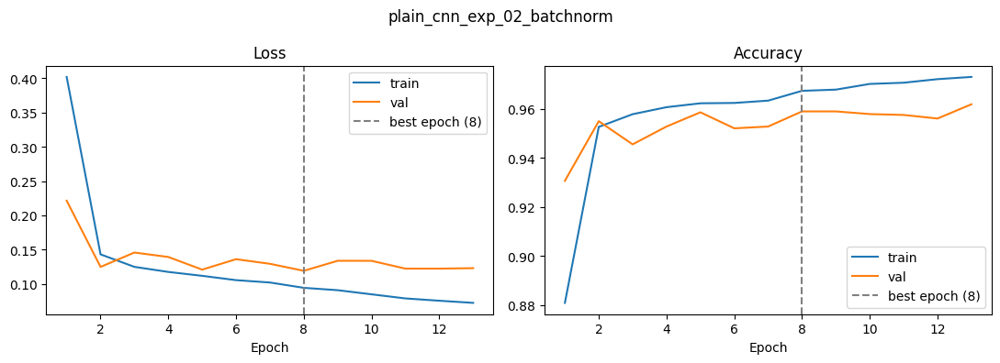

In [ ]:
# Experiment 2: add BatchNorm (single change vs exp 01)
result_02 = run_experiment(
    name="plain_cnn_exp_02_batchnorm",
    change="exp 01 + BatchNorm after every conv (Conv→BN→ReLU, no conv bias)",
    model_kwargs=dict(
        convs_per_block=1,
        batch_norm=True,   # only change
        head="flatten",
        dropout=0.0,
        l2=0.0,
    ),
    train_ds=train_ds,
    val_ds=val_ds,
    lr=1e-3,
    augmentation="none",
    seed=42,
)
plot_curves(result_02)

**Result:** best epoch 8 of 13. Validation: accuracy 0.9590, precision 0.9788, sensitivity 0.9383, specificity 0.9797, F1 0.9581, AUC 0.9904, val_loss 0.1192 (exp 01: 0.9565 / 0.9474 / 0.9666 / 0.9463 / 0.9569 / 0.9918 / 0.1188). Accuracy (+0.25 pp, about 7 images), val_loss and AUC are unchanged within noise. The operating point moved: sensitivity -2.8 pp, specificity +3.3 pp. Training lasted longer before overfitting (best epoch 8 vs 4).
**Decision:** **BatchNorm is a tie, not a win.** It did not improve val_loss, AUC or accuracy, and it traded sensitivity for specificity. It stays in the base configuration because every later experiment builds on it and it trains for more epochs before overfitting, but its benefit is not demonstrated: a no-BN + augmentation run was never made. *Caveat:* single seed.

### Experiment 3: Augmentation
**Hypothesis:** random flips and rotations (label-preserving for cells) act as regularisation, narrowing the train/val gap and possibly improving sensitivity.
**Change (only this):** exp 02 + augmentation on the **training set only**. The model itself is unchanged.
**Exact settings (for the report):** horizontal + vertical flips; rotation uniform in **±36°** (`RandomRotation(0.1)` = 0.1 of a full turn), corners filled with black; validation and test are never augmented.
**Watch for:** augmentation slows convergence, so check whether the best epoch is close to the 25-epoch cap. If it is, the budget is limiting this run and the comparison with exp 02 is not fair.


In [ ]:
# Experiment 3: add augmentation (single change vs exp 02)
train_ds_aug = make_dataset("train", shuffle=True, augment=True)

result_03 = run_experiment(
    name="plain_cnn_exp_03_augmentation",
    change="exp 02 + flips and ±36° rotation augmentation on train only",
    model_kwargs=dict(convs_per_block=1, batch_norm=True, head="flatten", dropout=0.0, l2=0.0),
    train_ds=train_ds_aug,   # only change: augmented training set
    val_ds=val_ds,
    lr=1e-3,
    augmentation="flip_hv+rot36deg",
    seed=SEED,
)
summarize(result_03)

Epoch 1/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 74s 97ms/step - accuracy: 0.8845 - auc: 0.9423 - loss: 0.3691 - precision: 0.9029 - recall: 0.8616 - val_accuracy: 0.9463 - val_auc: 0.9848 - val_loss: 0.1546 - val_precision: 0.9760 - val_recall: 0.9151
Epoch 2/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 58s 84ms/step - accuracy: 0.9507 - auc: 0.9846 - loss: 0.1480 - precision: 0.9658 - recall: 0.9346 - val_accuracy: 0.9568 - val_auc: 0.9898 - val_loss: 0.1257 - val_precision: 0.9680 - val_recall: 0.9448
Epoch 3/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 58s 83ms/step - accuracy: 0.9551 - auc: 0.9870 - loss: 0.1347 - precision: 0.9657 - recall: 0.9438 - val_accuracy: 0.9601 - val_auc: 0.9889 - val_loss: 0.1298 - val_precision: 0.9703 - val_recall: 0.9492
Epoch 4/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 55s 80ms/step - accuracy: 0.9559 - auc: 0.9876 - loss: 0.1307 - precision: 0.9675 - recall: 0.9434 - val_accuracy: 0.9550 - val_auc: 0.9894 - val_loss: 0.1271 - val_precision: 0.9714 - val_recall: 0.9376
Epoch 5/25
689/689 ━━━━━

,0
run,plain_cnn_exp_03_augmentation
change,exp 02 + flips and ±36° rotation augmentation ...
architecture,plain_4blk_c1_bn_flatten
learning_rate,0.001
optimizer,adam
batch_size,32
max_epochs,25
epochs_run,18
augmentation,flip_hv+rot36deg
strategy,from_scratch


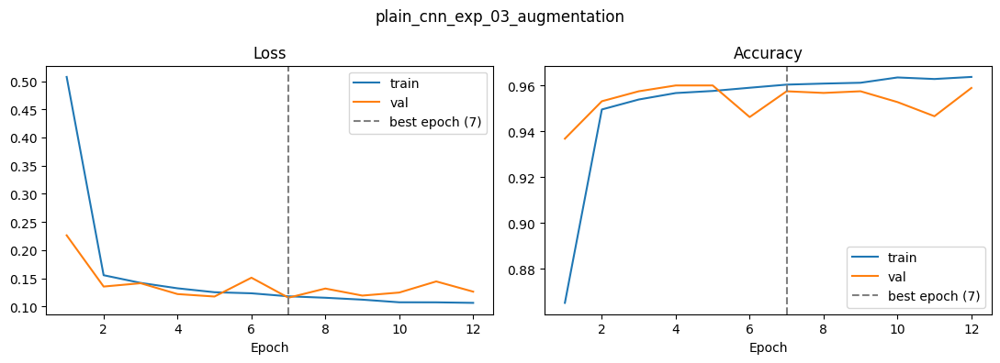

epochs run: 12/25, best epoch: 7


In [ ]:
plot_curves(result_03)

# Fairness check: did the 25-epoch budget limit this run?
print(f"epochs run: {result_03['epochs_run']}/{MAX_EPOCHS}, best epoch: {result_03['best_epoch']}")
if result_03["best_epoch"] >= MAX_EPOCHS - 2:
    print("Best epoch is near the cap: the budget may be limiting this run.")

**Result:** early stopped at epoch 18, best epoch 13 (early stopping, not the cap, ended the run). Validation: accuracy **0.9637**, precision 0.9699, sensitivity 0.9572, specificity 0.9702, F1 0.9635, AUC 0.9929, val_loss **0.1023** (exp 02: 0.9590 / 0.9788 / 0.9383 / 0.9797 / 0.9581 / 0.9904 / 0.1192). At the best epoch train loss is 0.107 vs val 0.102, so the overfitting gap of exp 01/02 is closed. val_loss improved by 0.017, more than the noise threshold; accuracy +0.5 pp and sensitivity +1.9 pp sit at the edge of it.
**Decision:** **keep augmentation.** The val_loss drop and the closed train/val gap are consistent evidence; the accuracy and sensitivity gains alone would not be enough. *Caveat:* single seed, and picking the best epoch of a noisy curve flatters the number.

### Experiment 4: Dropout
**Hypothesis:** dropout in the head reduces reliance on individual units in the large Flatten→Dense(128) layer (16,384×128 weights, most of the model). *Honest expectation:* exp 03 already closed most of the train/val gap, so the gain may be small or zero; a null result is still informative.
**Change (only this):** exp 03 + `Dropout(0.5)` after `Dense(128)`. Augmentation stays on, as decided in exp 03.

In [ ]:
# Experiment 4: add dropout in the head (single change vs exp 03; augmentation stays on)
result_04 = run_experiment(
    name="plain_cnn_exp_04_dropout",
    change="exp 03 + Dropout(0.5) after the Dense(128) head layer",
    model_kwargs=dict(convs_per_block=1, batch_norm=True, head="flatten", dropout=0.5, l2=0.0),
    train_ds=train_ds_aug,   # same augmented training set as exp 03
    val_ds=val_ds,
    lr=1e-3,
    augmentation="flip_hv+rot36deg",
    seed=SEED,
)
summarize(result_04)

Epoch 1/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 73s 97ms/step - accuracy: 0.6426 - auc: 0.7004 - loss: 0.6732 - precision: 0.5958 - recall: 0.8868 - val_accuracy: 0.8824 - val_auc: 0.9775 - val_loss: 0.2927 - val_precision: 0.8190 - val_recall: 0.9819
Epoch 2/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 57s 83ms/step - accuracy: 0.8228 - auc: 0.9238 - loss: 0.3613 - precision: 0.8051 - recall: 0.8519 - val_accuracy: 0.9510 - val_auc: 0.9871 - val_loss: 0.1728 - val_precision: 0.9777 - val_recall: 0.9231
Epoch 3/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 82s 83ms/step - accuracy: 0.9189 - auc: 0.9525 - loss: 0.2805 - precision: 0.9683 - recall: 0.8662 - val_accuracy: 0.9583 - val_auc: 0.9900 - val_loss: 0.1483 - val_precision: 0.9716 - val_recall: 0.9441
Epoch 4/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 60s 86ms/step - accuracy: 0.9204 - auc: 0.9568 - loss: 0.2488 - precision: 0.9707 - recall: 0.8671 - val_accuracy: 0.9503 - val_auc: 0.9872 - val_loss: 0.1690 - val_precision: 0.9755 - val_recall: 0.9238
Epoch 5/25
689/689 ━━━━━

,0
run,plain_cnn_exp_04_dropout
change,exp 03 + Dropout(0.5) after the Dense(128) hea...
architecture,plain_4blk_c1_bn_flatten
learning_rate,0.001
optimizer,adam
batch_size,32
max_epochs,25
epochs_run,22
augmentation,flip_hv+rot36deg
strategy,from_scratch


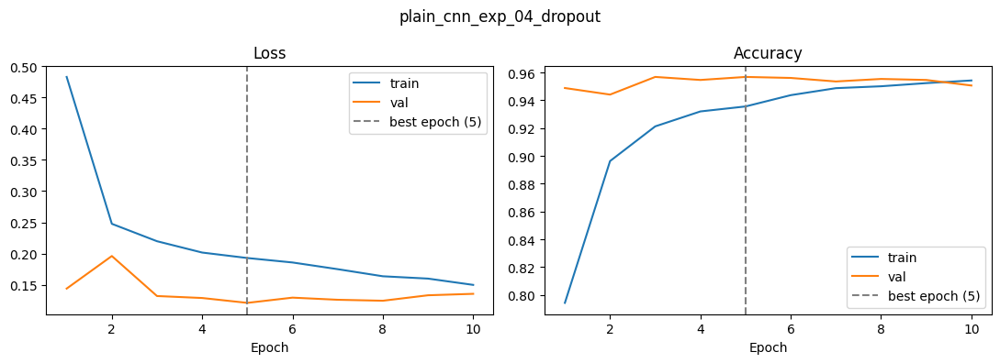

epochs 10/25, best epoch 5 -> early stopping, not the cap, decided


In [ ]:
plot_curves(result_04)

# Was the epoch budget limiting? Only if all epochs ran AND the best epoch is within PATIENCE of the cap.
r = result_04
cut_off = r["epochs_run"] == MAX_EPOCHS and r["best_epoch"] > MAX_EPOCHS - PATIENCE
print(f"epochs {r['epochs_run']}/{MAX_EPOCHS}, best epoch {r['best_epoch']} -> "
      f"{'budget may be limiting' if cut_off else 'early stopping, not the cap, decided'}")

**Result:** early stopped at epoch 22, best epoch 17. Validation: accuracy 0.9619, precision 0.9818, sensitivity 0.9412, specificity 0.9826, F1 0.9611, AUC 0.9929, val_loss 0.1077 (exp 03: 0.9637 / 0.9699 / 0.9572 / 0.9702 / 0.9635 / 0.9929 / 0.1023). Accuracy, AUC and val_loss are tied with exp 03 (within noise). Dropout again moved the threshold toward specificity (+1.2 pp) at the cost of sensitivity (-1.6 pp). Train loss stays above val loss (0.134 vs 0.108 at the best epoch) because dropout and augmentation are both active in training.
**Decision:** **drop dropout.** It gives no measurable gain and costs sensitivity, the clinically more important number. *Caveats:* only p=0.5 tried; single seed. Experiment 5 branches from the exp 03 configuration.

### Helper: validation noise
Measures how much `val_loss` jumps from one epoch to the next (lower = steadier training). Used to compare how stable runs are.

In [ ]:
def val_noise(result: dict, upto: int | None = None, skip: int = 2) -> float:
    """Mean absolute epoch-to-epoch change in val_loss (lower = more stable training).
    skip drops the warm-up epochs; upto compares runs over the same epoch span."""
    v = np.array(result["history"].history["val_loss"])[skip:upto]
    return float(np.mean(np.abs(np.diff(v))))

print("exp 03:", round(val_noise(result_03), 4), "| first 11 epochs:", round(val_noise(result_03, upto=11), 4))
print("exp 04:", round(val_noise(result_04), 4))

exp 03: 0.0141 | first 11 epochs: 0.0063
exp 04: 0.0127


### Experiment 5: Lower learning rate
**Hypothesis:** the validation curves of the augmented runs show epoch-to-epoch swings in precision and recall, which suggests lr 1e-3 may be too aggressive for the late epochs. A lower lr should give a smoother curve and a lower val_loss, but converges more slowly.
**Change (only this):** lr 1e-3 → 3e-4, on the exp 03 configuration (BN + augmentation, no dropout). Same 25-epoch budget.

In [ ]:
# Experiment 5: lower learning rate (single change vs exp 03; dropout back to 0)
result_05 = run_experiment(
    name="plain_cnn_exp_05_lr_3e-4",
    change="exp 03 with learning rate 1e-3 -> 3e-4",
    model_kwargs=dict(convs_per_block=1, batch_norm=True, head="flatten", dropout=0.0, l2=0.0),
    train_ds=train_ds_aug, val_ds=val_ds,
    lr=3e-4,                       # only change
    augmentation="flip_hv+rot36deg", seed=SEED,
)
summarize(result_05)

Epoch 1/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 68s 91ms/step - accuracy: 0.8809 - auc: 0.9469 - loss: 0.3077 - precision: 0.8929 - recall: 0.8656 - val_accuracy: 0.8759 - val_auc: 0.9808 - val_loss: 0.2778 - val_precision: 0.8136 - val_recall: 0.9753
Epoch 2/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 56s 80ms/step - accuracy: 0.9501 - auc: 0.9841 - loss: 0.1504 - precision: 0.9588 - recall: 0.9408 - val_accuracy: 0.9543 - val_auc: 0.9883 - val_loss: 0.1384 - val_precision: 0.9735 - val_recall: 0.9340
Epoch 3/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 81s 80ms/step - accuracy: 0.9537 - auc: 0.9866 - loss: 0.1370 - precision: 0.9625 - recall: 0.9443 - val_accuracy: 0.9539 - val_auc: 0.9875 - val_loss: 0.1357 - val_precision: 0.9562 - val_recall: 0.9514
Epoch 4/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 56s 81ms/step - accuracy: 0.9565 - auc: 0.9874 - loss: 0.1319 - precision: 0.9632 - recall: 0.9492 - val_accuracy: 0.9557 - val_auc: 0.9909 - val_loss: 0.1180 - val_precision: 0.9708 - val_recall: 0.9398
Epoch 5/25
689/689 ━━━━━

,0
run,plain_cnn_exp_05_lr_3e-4
change,exp 03 with learning rate 1e-3 -> 3e-4
architecture,plain_4blk_c1_bn_flatten
learning_rate,0.0003
optimizer,adam
batch_size,32
max_epochs,25
epochs_run,16
augmentation,flip_hv+rot36deg
strategy,from_scratch


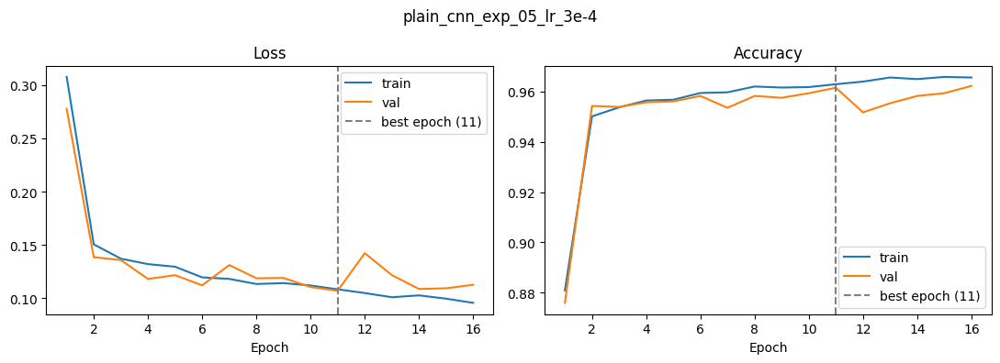

epochs 16/25, best epoch 11 -> early stopping, not the cap, decided
val_noise: 0.0113 | first 11 epochs: 0.0093


In [ ]:
plot_curves(result_05)
r = result_05
cut_off = r["epochs_run"] == MAX_EPOCHS and r["best_epoch"] > MAX_EPOCHS - PATIENCE
print(f"epochs {r['epochs_run']}/{MAX_EPOCHS}, best epoch {r['best_epoch']} -> "
      f"{'budget may be limiting' if cut_off else 'early stopping, not the cap, decided'}")
print("val_noise:", round(val_noise(r), 4), "| first 11 epochs:", round(val_noise(r, upto=11), 4))

**Result:** early stopped at epoch 16, best epoch 11. Validation: accuracy 0.9615, precision 0.9697, sensitivity 0.9528, specificity 0.9702, F1 0.9612, AUC 0.9924, val_loss 0.1069 (exp 03: 0.9637 / 0.9699 / 0.9572 / 0.9702 / 0.9635 / 0.9929 / 0.1023). Every metric is within noise of exp 03; the lower lr did not converge faster or higher.
**Decision:** **keep lr 1e-3** (tie, and the exp 03 configuration remains the base). *Caveat:* single seed.

### Experiment 6: Global average pooling head
**Hypothesis:** 84% of the parameters sit in the Flatten→Dense(128) layer. Replacing Flatten with GlobalAveragePooling (-83% parameters) should regularise the head and reduce the precision/recall swings seen in exp 03 and 05, possibly at a small cost in accuracy.
**Change (only this):** `head="gap"` on the exp 03 configuration (BN + augmentation, lr 1e-3, no dropout).

In [ ]:
# Experiment 6: GAP head (single change vs exp 03)
result_06 = run_experiment(
    name="plain_cnn_exp_06_gap_head",
    change="exp 03 with Flatten head replaced by GlobalAveragePooling (-83% params)",
    model_kwargs=dict(convs_per_block=1, batch_norm=True, head="gap", dropout=0.0, l2=0.0),
    train_ds=train_ds_aug, val_ds=val_ds,
    lr=1e-3, augmentation="flip_hv+rot36deg", seed=SEED,
)
summarize(result_06)

Epoch 1/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 68s 88ms/step - accuracy: 0.9205 - auc: 0.9700 - loss: 0.2163 - precision: 0.9391 - recall: 0.8993 - val_accuracy: 0.9546 - val_auc: 0.9877 - val_loss: 0.1409 - val_precision: 0.9556 - val_recall: 0.9536
Epoch 2/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 58s 84ms/step - accuracy: 0.9521 - auc: 0.9835 - loss: 0.1472 - precision: 0.9632 - recall: 0.9401 - val_accuracy: 0.9539 - val_auc: 0.9889 - val_loss: 0.1477 - val_precision: 0.9786 - val_recall: 0.9282
Epoch 3/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 79s 81ms/step - accuracy: 0.9540 - auc: 0.9856 - loss: 0.1405 - precision: 0.9626 - recall: 0.9446 - val_accuracy: 0.9565 - val_auc: 0.9912 - val_loss: 0.1248 - val_precision: 0.9708 - val_recall: 0.9412
Epoch 4/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 55s 80ms/step - accuracy: 0.9573 - auc: 0.9877 - loss: 0.1299 - precision: 0.9650 - recall: 0.9491 - val_accuracy: 0.9568 - val_auc: 0.9886 - val_loss: 0.1337 - val_precision: 0.9632 - val_recall: 0.9499
Epoch 5/25
689/689 ━━━━━

,0
run,plain_cnn_exp_06_gap_head
change,exp 03 with Flatten head replaced by GlobalAve...
architecture,plain_4blk_c1_bn_gap
learning_rate,0.001
optimizer,adam
batch_size,32
max_epochs,25
epochs_run,8
augmentation,flip_hv+rot36deg
strategy,from_scratch


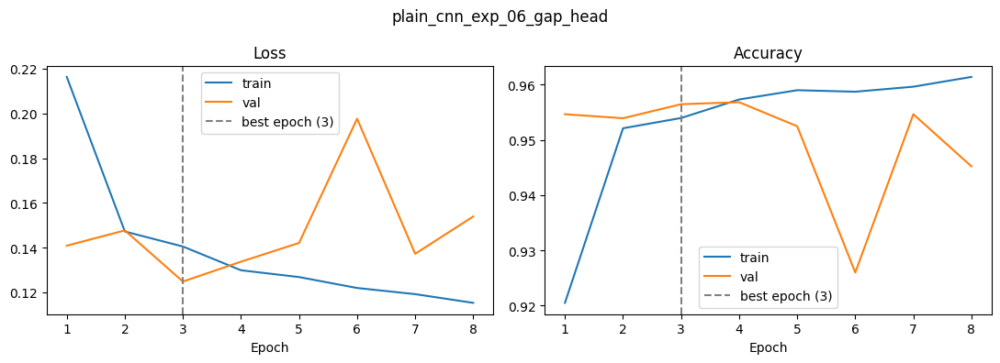

epochs 8/25, best epoch 3 -> early stopping, not the cap, decided
val_noise: 0.03 | first 11 epochs: 0.03


In [ ]:
plot_curves(result_06)
r = result_06
cut_off = r["epochs_run"] == MAX_EPOCHS and r["best_epoch"] > MAX_EPOCHS - PATIENCE
print(f"epochs {r['epochs_run']}/{MAX_EPOCHS}, best epoch {r['best_epoch']} -> "
      f"{'budget may be limiting' if cut_off else 'early stopping, not the cap, decided'}")
print("val_noise:", round(val_noise(r), 4), "| first 11 epochs:", round(val_noise(r, upto=11), 4))

**Result:** early stopped at epoch 8, best epoch 3. Validation: accuracy 0.9565, precision 0.9708, sensitivity 0.9412, specificity 0.9717, F1 0.9558, AUC 0.9913, val_loss 0.1248 (exp 03: 0.9637 / 0.9699 / 0.9572 / 0.9702 / 0.9635 / 0.9929 / 0.1023), with 422,881 parameters (-83%). This is the only change in the table that clearly exceeds noise: accuracy -0.7 pp (about 20 images) and val_loss +0.023.
**Decision:** **drop the GAP head.** Flatten keeps the spatial layout of the 16×16 feature map, which this task apparently uses. *Caveat:* early stopping fired at epoch 8 after a validation spike, so a longer patience might have recovered some of the gap; single seed.

### Experiment 7: Deeper blocks
**Hypothesis:** a second 3×3 conv per block (conv-conv-pool, as in VGG) adds capacity and a larger receptive field at each scale, which should lower val_loss and improve sensitivity, at the cost of more parameters and compute.
**Change (only this):** `convs_per_block=2` on the exp 03 configuration (BN + augmentation, lr 1e-3, no dropout; 3,272,545 parameters, +31.6%).

In [ ]:
# Experiment 7: deeper blocks (single change vs exp 03)
result_07 = run_experiment(
    name="plain_cnn_exp_07_two_convs_per_block",
    change="exp 03 with 2 convs per block (deeper blocks)",
    model_kwargs=dict(convs_per_block=2, batch_norm=True, head="flatten", dropout=0.0, l2=0.0),
    train_ds=train_ds_aug, val_ds=val_ds,
    lr=1e-3, augmentation="flip_hv+rot36deg", seed=SEED,
)
summarize(result_07)

Epoch 1/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 101s 118ms/step - accuracy: 0.9174 - auc: 0.9700 - loss: 0.2761 - precision: 0.9296 - recall: 0.9033 - val_accuracy: 0.9565 - val_auc: 0.9860 - val_loss: 0.1435 - val_precision: 0.9729 - val_recall: 0.9390
Epoch 2/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 63s 91ms/step - accuracy: 0.9554 - auc: 0.9850 - loss: 0.1385 - precision: 0.9614 - recall: 0.9489 - val_accuracy: 0.9554 - val_auc: 0.9862 - val_loss: 0.1553 - val_precision: 0.9531 - val_recall: 0.9579
Epoch 3/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 62s 90ms/step - accuracy: 0.9575 - auc: 0.9868 - loss: 0.1310 - precision: 0.9636 - recall: 0.9509 - val_accuracy: 0.9583 - val_auc: 0.9894 - val_loss: 0.1248 - val_precision: 0.9560 - val_recall: 0.9608
Epoch 4/25
689/689 ━━━━━━━━━━━━━━━━━━━━ 65s 94ms/step - accuracy: 0.9571 - auc: 0.9869 - loss: 0.1305 - precision: 0.9652 - recall: 0.9485 - val_accuracy: 0.9546 - val_auc: 0.9824 - val_loss: 0.1474 - val_precision: 0.9735 - val_recall: 0.9347
Epoch 5/25
689/689 ━━━

,0
run,plain_cnn_exp_07_two_convs_per_block
change,exp 03 with 2 convs per block (deeper blocks)
architecture,plain_4blk_c2_bn_flatten
learning_rate,0.001
optimizer,adam
batch_size,32
max_epochs,25
epochs_run,25
augmentation,flip_hv+rot36deg
strategy,from_scratch


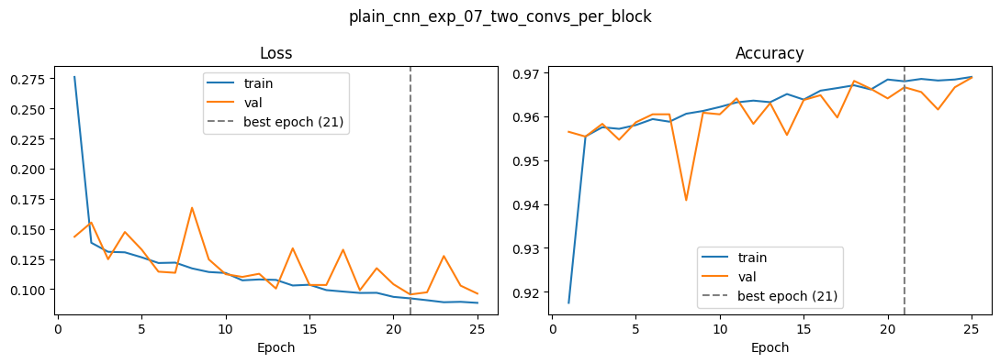

epochs 25/25, best epoch 21 -> budget may be limiting
val_noise: 0.0188 | first 11 epochs: 0.021


In [ ]:
plot_curves(result_07)
r = result_07
cut_off = r["epochs_run"] == MAX_EPOCHS and r["best_epoch"] > MAX_EPOCHS - PATIENCE
print(f"epochs {r['epochs_run']}/{MAX_EPOCHS}, best epoch {r['best_epoch']} -> "
      f"{'budget may be limiting' if cut_off else 'early stopping, not the cap, decided'}")
print("val_noise:", round(val_noise(r), 4), "| first 11 epochs:", round(val_noise(r, upto=11), 4))

**Result:** ran all 25 epochs, best epoch 21. Validation: accuracy **0.9666**, precision 0.9639, sensitivity **0.9695**, specificity 0.9637, F1 0.9667, AUC **0.9938**, val_loss **0.0955** (exp 03: 0.9637 / 0.9699 / 0.9572 / 0.9702 / 0.9635 / 0.9929 / 0.1023). Train loss 0.092 vs val 0.096 at the best epoch, so there is no overfitting gap. Every difference from exp 03 is inside the noise threshold (accuracy +0.3 pp, val_loss -0.007, sensitivity +1.2 pp, specificity -0.7 pp).
**Decision:** exp 07 has the lowest val_loss and the highest sensitivity, so it is the **final candidate under the pre-set selection rule** (lowest val_loss, sensitivity as tiebreak), but it is **statistically tied with exp 03**, which is 24% smaller. *Budget caveat:* the best epoch (21) is within patience of the 25-epoch cap, so the cap may have stopped the run early; that can only understate exp 07.

### TensorBoard log check
Check that each run's TensorBoard folder matches `results.csv` (same number of epochs, no duplicate event files).


In [ ]:
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator


def event_files(d: Path) -> list[Path]:
    """Event files directly in d, oldest first (the filename embeds the unix timestamp)."""
    return sorted(d.glob("events.out.tfevents.*")) if d.exists() else []


def logged_epochs(run: str) -> int:
    """Epochs in the NEWEST validation log (the last run written here); 0 if none found."""
    files = event_files(LOG_DIR / run / "validation")
    if not files:
        return 0
    # Keras writes epoch metrics as tensor summaries; size_guidance 0 = keep every event
    ea = EventAccumulator(str(files[-1]), size_guidance={"tensors": 0})
    ea.Reload()
    tags = ea.Tags()["tensors"]
    if "epoch_loss" not in tags:
        print(f"  {run}: no epoch_loss in {files[-1].name}; tensor tags: {tags}")
        return 0
    return len(ea.Tensors("epoch_loss"))


def audit_logs() -> pd.DataFrame:
    """One row per run in results.csv: event-file counts, and do the logs match the CSV?"""
    rows = []
    for _, r in pd.read_csv(RESULTS_CSV).iterrows():
        run = r["run"]
        rows.append({
            "run": run,
            "train_files": len(event_files(LOG_DIR / run / "train")),
            "val_files": len(event_files(LOG_DIR / run / "validation")),
            "root_files": len(event_files(LOG_DIR / run)),
            "logged_epochs": logged_epochs(run),
            "csv_epochs": int(r["epochs_run"]),
        })
    df = pd.DataFrame(rows)
    df["status"] = np.select(
        [df.logged_epochs != df.csv_epochs, (df.train_files > 1) | (df.val_files > 1)],
        ["MISMATCH -> re-run", "DUPLICATES -> clean"], default="ok")
    return df


pd.set_option("display.width", 200)
print(audit_logs().to_string(index=False))

# Folders in logs/ that are not in results.csv (leftovers such as smoke tests)
known = set(pd.read_csv(RESULTS_CSV)["run"])
print("Untracked folders:", [p.name for p in LOG_DIR.iterdir() if p.is_dir() and p.name not in known])

                                 run  train_files  val_files  root_files  logged_epochs  csv_epochs              status
           plain_cnn_exp_01_baseline            1          1           2              9           9                  ok
          plain_cnn_exp_02_batchnorm            1          1           2             13          13                  ok
            plain_cnn_exp_05_lr_3e-4            1          1           2             16          16                  ok
           plain_cnn_exp_06_gap_head            1          1           2              8           8                  ok
plain_cnn_exp_07_two_convs_per_block            1          1           1             25          25                  ok
       plain_cnn_exp_03_augmentation            2          2           3             18          18 DUPLICATES -> clean
            plain_cnn_exp_04_dropout            2          2           3             22          22 DUPLICATES -> clean
Untracked folders: []


### Clean the logs
Keep only the newest event file per run and rewrite its HParams row. Stops if a run's logs and CSV disagree. A backup copy is made first.


In [ ]:
def clean_run_logs(run: str) -> None:
    """Keep only the newest train/validation event file; delete root files (hparams + final_*)."""
    for sub in ("train", "validation"):
        for f in event_files(LOG_DIR / run / sub)[:-1]:   # all but the newest
            f.unlink()
    for f in event_files(LOG_DIR / run):                  # root holds only hparams/final_*, rewritten below
        f.unlink()


def backfill_hparams(runs: list[str]) -> None:
    """Rewrite HParams + final metrics from results.csv; rows are labelled with the run name."""
    df = pd.read_csv(RESULTS_CSV).fillna({"strategy": "from_scratch"})
    keys = ["architecture", "learning_rate", "optimizer", "batch_size", "max_epochs",
            "epochs_run", "augmentation", "strategy", "dropout", "l2"]
    py = lambda v: v.item() if hasattr(v, "item") else v   # numpy scalar -> python type
    for _, r in df[df["run"].isin(runs)].iterrows():
        writer = tf.summary.create_file_writer(str(LOG_DIR / r["run"]))
        with writer.as_default():
            hp.hparams({k: py(r[k]) for k in keys}, trial_id=r["run"])
            for k in (*SCALAR_METRICS, "recall"):          # recall = sensitivity alias
                tf.summary.scalar(f"final_{k}", float(r["sensitivity" if k == "recall" else k]), step=1)
        writer.close()


# Guard: never clean a run whose logs and CSV disagree
audit = audit_logs()
assert not (audit.status == "MISMATCH -> re-run").any(), "Re-run the MISMATCH runs first"

# Safety net: copy logs outside logs/ so TensorBoard and the final zip ignore it
backup = ROOT / "logs_backup"
if not backup.exists():
    shutil.copytree(LOG_DIR, backup)

runs = audit["run"].tolist()
for run in runs:
    clean_run_logs(run)
backfill_hparams(runs)

print(audit_logs().to_string(index=False))   # expect: status ok and root_files == 1 for all 7

                                 run  train_files  val_files  root_files  logged_epochs  csv_epochs status
           plain_cnn_exp_01_baseline            1          1           1              9           9     ok
          plain_cnn_exp_02_batchnorm            1          1           1             13          13     ok
            plain_cnn_exp_05_lr_3e-4            1          1           1             16          16     ok
           plain_cnn_exp_06_gap_head            1          1           1              8           8     ok
plain_cnn_exp_07_two_convs_per_block            1          1           1             25          25     ok
       plain_cnn_exp_03_augmentation            1          1           1             18          18     ok
            plain_cnn_exp_04_dropout            1          1           1             22          22     ok


### Backfill `val_loss` into `results.csv`
Experiments 01-06 ran before `val_loss` was added to the results row. This one-off cell fills it from each run's `history.json` (the best epoch's value) and checks that every history file matches its row in `results.csv` (same number of epochs, same best epoch). Safe to re-run. On a fresh run it only confirms the values.


In [ ]:
def backfill_val_loss() -> pd.DataFrame:
    """Fill results.csv 'val_loss' (best epoch's value) from each run's history.json."""
    shutil.copy(RESULTS_CSV, RESULTS_CSV.with_name("results_backup.csv"))   # safety net
    df = pd.read_csv(RESULTS_CSV)
    best = []
    for _, r in df.iterrows():
        h = json.loads((LOG_DIR / r["run"] / "history.json").read_text())
        # history.json must come from the same run as this CSV row
        assert len(h["loss"]) == r["epochs_run"], f'{r["run"]}: epochs differ'
        assert int(np.argmin(h["val_loss"])) + 1 == r["best_epoch"], f'{r["run"]}: best epoch differs'
        best.append(float(min(h["val_loss"])))   # restore_best_weights -> best epoch's val_loss
    df["val_loss"] = best
    df.to_csv(RESULTS_CSV, index=False)
    return df[["run", "best_epoch", "val_loss"]]


print(backfill_val_loss().to_string(index=False))

                                 run  best_epoch  val_loss
           plain_cnn_exp_01_baseline           4  0.118815
          plain_cnn_exp_02_batchnorm           8  0.119244
            plain_cnn_exp_05_lr_3e-4          11  0.106883
           plain_cnn_exp_06_gap_head           3  0.124812
plain_cnn_exp_07_two_convs_per_block          21  0.095538
       plain_cnn_exp_03_augmentation          13  0.102323
            plain_cnn_exp_04_dropout          17  0.107733


### TensorBoard

In [ ]:
!pkill -f tensorboard
%load_ext tensorboard
%tensorboard --logdir "/content/drive/MyDrive/ml-formative-2/model4/logs"

<IPython.core.display.Javascript object>

## Results
All results come from the saved runs. Order: summary table → curves → model selection → one test evaluation → plots → Grad-CAM → error analysis.

### 1. Experiment summary (validation set)
One row per run, straight from `results.csv`.

In [ ]:
cols = ["run", "best_epoch", "epochs_run", "accuracy", "precision", "sensitivity",
        "specificity", "f1", "auc", "val_loss", "params"]
table = pd.read_csv(RESULTS_CSV).sort_values("run")[cols]
print(table.round(4).to_string(index=False))

                                 run  best_epoch  epochs_run  accuracy  precision  sensitivity  specificity     f1    auc  val_loss  params
           plain_cnn_exp_01_baseline           4           9    0.9565     0.9474       0.9666       0.9463 0.9569 0.9918    0.1188 2485825
          plain_cnn_exp_02_batchnorm           8          13    0.9590     0.9788       0.9383       0.9797 0.9581 0.9904    0.1192 2487265
       plain_cnn_exp_03_augmentation          13          18    0.9637     0.9699       0.9572       0.9702 0.9635 0.9929    0.1023 2487265
            plain_cnn_exp_04_dropout          17          22    0.9619     0.9818       0.9412       0.9826 0.9611 0.9929    0.1077 2487265
            plain_cnn_exp_05_lr_3e-4          11          16    0.9615     0.9697       0.9528       0.9702 0.9612 0.9924    0.1069 2487265
           plain_cnn_exp_06_gap_head           3           8    0.9565     0.9708       0.9412       0.9717 0.9558 0.9913    0.1248  422881
plain_cnn_exp_07_two

### 2. Learning curves for every run
The table shows train vs validation loss at the best and last epoch. A big gap at the last epoch means overfitting. The plots show the same thing per run.

                                 run  best_ep  last_ep  train@best  val@best  train@last  val@last
           plain_cnn_exp_01_baseline        4        9      0.1052    0.1188      0.0374    0.1965
          plain_cnn_exp_02_batchnorm        8       13      0.0945    0.1192      0.0726    0.1231
       plain_cnn_exp_03_augmentation       13       18      0.1067    0.1023      0.0989    0.1026
            plain_cnn_exp_04_dropout       17       22      0.1338    0.1077      0.1203    0.1230
            plain_cnn_exp_05_lr_3e-4       11       16      0.1082    0.1069      0.0955    0.1125
           plain_cnn_exp_06_gap_head        3        8      0.1405    0.1248      0.1153    0.1539
plain_cnn_exp_07_two_convs_per_block       21       25      0.0923    0.0955      0.0886    0.0963


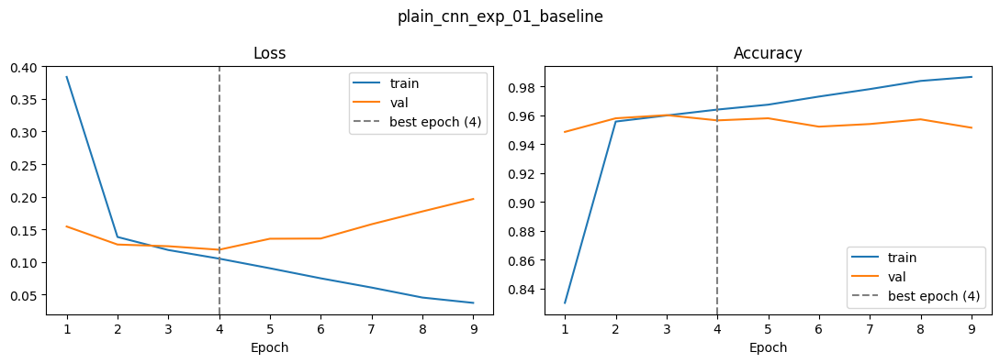

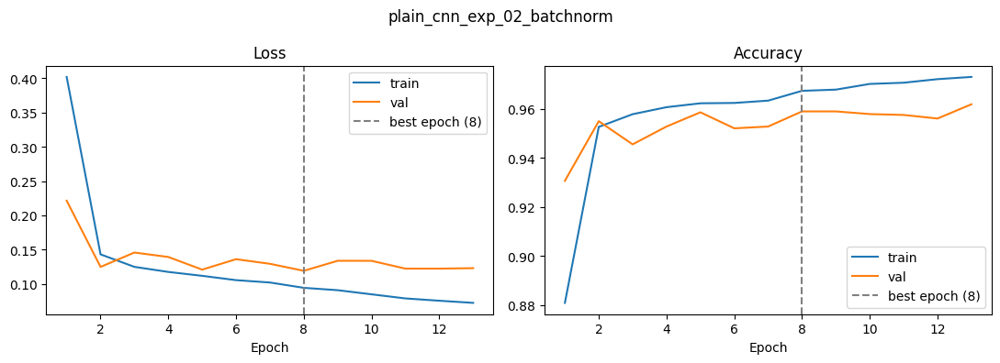

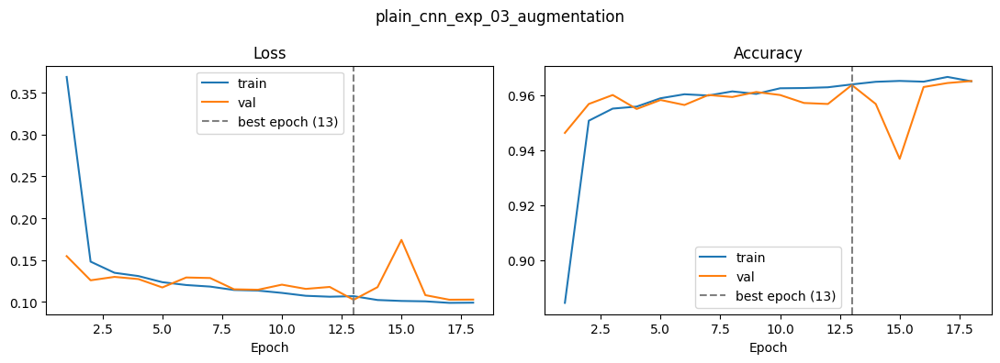

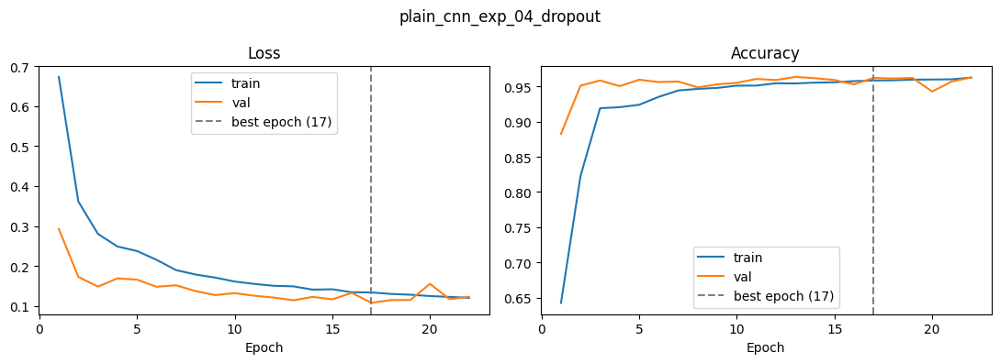

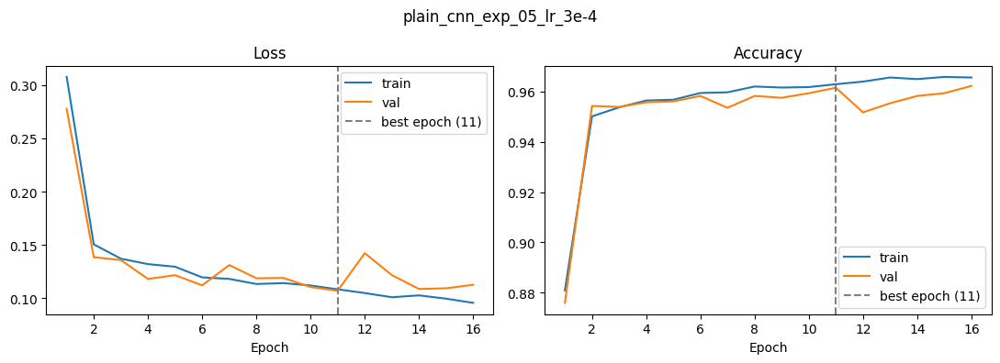

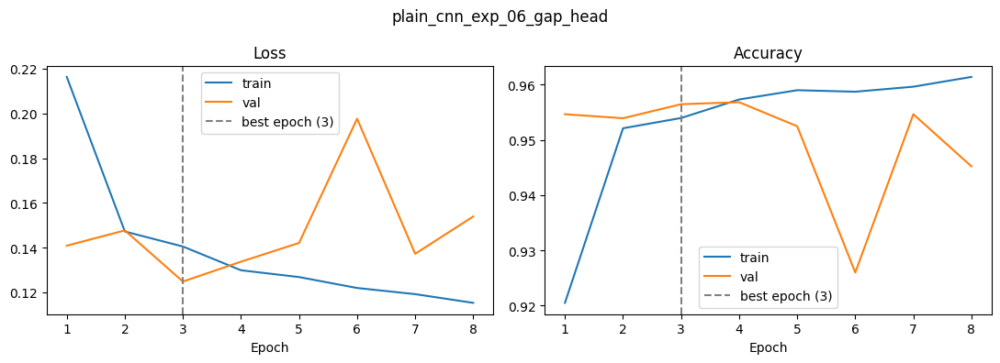

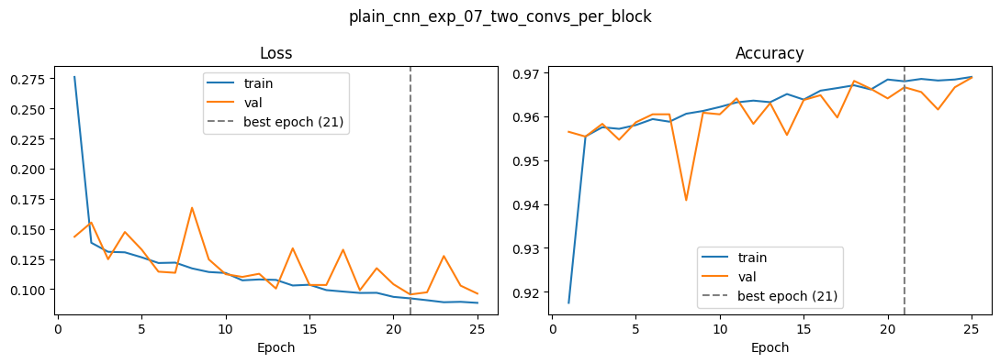

In [ ]:
from types import SimpleNamespace


def load_result(run: str) -> dict:
    """Rebuild a result dict from disk (results.csv + history.json), so no retraining is needed."""
    row = pd.read_csv(RESULTS_CSV).set_index("run").loc[run]
    history = json.loads((LOG_DIR / run / "history.json").read_text())
    return {"run": run, "best_epoch": int(row["best_epoch"]), "epochs_run": int(row["epochs_run"]),
            "history": SimpleNamespace(history=history)}   # mimics keras History.history


def loss_gap(run: str) -> dict:
    """Train/val loss at the best epoch and at the last epoch."""
    h = json.loads((LOG_DIR / run / "history.json").read_text())
    b = int(np.argmin(h["val_loss"]))
    return {"run": run, "best_ep": b + 1, "last_ep": len(h["loss"]),
            "train@best": h["loss"][b], "val@best": h["val_loss"][b],
            "train@last": h["loss"][-1], "val@last": h["val_loss"][-1]}


runs = sorted(pd.read_csv(RESULTS_CSV)["run"])
print(pd.DataFrame([loss_gap(r) for r in runs]).round(4).to_string(index=False))
for r in runs:
    plot_curves(load_result(r))   # regenerates every curve from the current history files

### 3. Fairness check: epoch cap and noise
`budget_limited` is True when a run used all 25 epochs and its best epoch is near the cap (the cap may have stopped it early). `val_noise` is the average epoch-to-epoch change in `val_loss`.

In [ ]:
# per-run epoch/budget/noise check, rebuilt from disk (no training)
def val_noise_h(h: dict, upto: int | None = None, skip: int = 2) -> float:
    """Mean |epoch-to-epoch change| in val_loss; skip drops warm-up epochs."""
    v = np.array(h["val_loss"])[skip:upto]
    return float(np.mean(np.abs(np.diff(v))))

rows = []
for run in sorted(pd.read_csv(RESULTS_CSV)["run"]):
    r = load_result(run)
    h = r["history"].history
    n, best = r["epochs_run"], r["best_epoch"]
    rows.append({
        "run": run, "epochs": f"{n}/{MAX_EPOCHS}", "best": best,
        "budget_limited": n == MAX_EPOCHS and best > MAX_EPOCHS - PATIENCE,
        "val_noise": round(val_noise_h(h), 4),
        "val_noise_11": round(val_noise_h(h, upto=11), 4),
    })
print(pd.DataFrame(rows).to_string(index=False))

                                 run epochs  best  budget_limited  val_noise  val_noise_11
           plain_cnn_exp_01_baseline   9/25     4           False     0.0139        0.0139
          plain_cnn_exp_02_batchnorm  13/25     8           False     0.0084        0.0104
       plain_cnn_exp_03_augmentation  18/25    13           False     0.0141        0.0063
            plain_cnn_exp_04_dropout  22/25    17           False     0.0127        0.0101
            plain_cnn_exp_05_lr_3e-4  16/25    11           False     0.0113        0.0093
           plain_cnn_exp_06_gap_head   8/25     3           False     0.0300        0.0300
plain_cnn_exp_07_two_convs_per_block  25/25    21            True     0.0188        0.0210


### 4. Model selection (rule fixed before any test evaluation)
The final model is the run with the **lowest validation loss**. Runs within the observed run-to-run noise (0.011 val_loss) count as tied, and **sensitivity** breaks the tie, since a missed infection is the costly error. The test set is evaluated once, on this model only. The next cell builds the comparison table and applies the rule.


In [ ]:
# comparison table (validation set), built straight from results.csv
CONFIG_NOTE = {
    "plain_cnn_exp_01_baseline": "1 conv/block, no BN, Flatten head",
    "plain_cnn_exp_02_batchnorm": "+ BatchNorm",
    "plain_cnn_exp_03_augmentation": "+ flips, ±36° rotation (train only)",
    "plain_cnn_exp_04_dropout": "exp 03 + Dropout 0.5",
    "plain_cnn_exp_05_lr_3e-4": "exp 03, lr 3e-4",
    "plain_cnn_exp_06_gap_head": "exp 03, GAP head",
    "plain_cnn_exp_07_two_convs_per_block": "exp 03, 2 convs/block",
}
METRICS = ["accuracy", "precision", "sensitivity", "specificity", "f1", "auc", "val_loss"]

df = pd.read_csv(RESULTS_CSV)
comparison = (df.sort_values("run")
                .assign(config=lambda d: d["run"].map(CONFIG_NOTE))
                .set_index("run")[["config", *METRICS]]
                .round(4))
display(comparison)
comparison.to_csv(RESULTS_CSV.with_name("comparison_table.csv"))

# apply the selection rule (lowest val_loss; runs within noise are tied -> best sensitivity)
NOISE_VAL_LOSS = 0.011
tied = df[df["val_loss"] <= df["val_loss"].min() + NOISE_VAL_LOSS]
selected = tied.sort_values("sensitivity", ascending=False).iloc[0]["run"]
print("Tied within noise:", sorted(tied["run"]))
print("Selected:", selected)

,config,accuracy,precision,sensitivity,specificity,f1,auc,val_loss
run,,,,,,,,
plain_cnn_exp_01_baseline,"1 conv/block, no BN, Flatten head",0.9565,0.9474,0.9666,0.9463,0.9569,0.9918,0.1188
plain_cnn_exp_02_batchnorm,+ BatchNorm,0.9590,0.9788,0.9383,0.9797,0.9581,0.9904,0.1192
plain_cnn_exp_03_augmentation,"+ flips, ±36° rotation (train only)",0.9637,0.9699,0.9572,0.9702,0.9635,0.9929,0.1023
plain_cnn_exp_04_dropout,exp 03 + Dropout 0.5,0.9619,0.9818,0.9412,0.9826,0.9611,0.9929,0.1077
plain_cnn_exp_05_lr_3e-4,"exp 03, lr 3e-4",0.9615,0.9697,0.9528,0.9702,0.9612,0.9924,0.1069
plain_cnn_exp_06_gap_head,"exp 03, GAP head",0.9565,0.9708,0.9412,0.9717,0.9558,0.9913,0.1248
plain_cnn_exp_07_two_convs_per_block,"exp 03, 2 convs/block",0.9666,0.9639,0.9695,0.9637,0.9667,0.9938,0.0955


Tied within noise: ['plain_cnn_exp_03_augmentation', 'plain_cnn_exp_07_two_convs_per_block']
Selected: plain_cnn_exp_07_two_convs_per_block


### 5. Final test evaluation
The selected model (exp 07) is loaded from its saved best-epoch checkpoint and evaluated once on the held-out test set. Targets: sensitivity ≥ 90% and specificity ≥ 90%. Wilson 95% intervals show how precisely each rate is estimated from 1,378 infected / 1,378 uninfected test cells. Predictions are saved so the plots, Grad-CAM and error analysis reuse them instead of touching the test set again.

In [ ]:
# single test evaluation of the selected model, with Wilson 95% CIs
TEST_NPZ = ROOT / "test_predictions.npz"
TARGET = 0.90


def wilson_ci(k: int, n: int, z: float = 1.96) -> tuple[float, float]:
    """Wilson score interval for a binomial proportion k/n."""
    p = k / n
    centre = (p + z**2 / (2 * n)) / (1 + z**2 / n)
    half = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / (1 + z**2 / n)
    return centre - half, centre + half


final_model = keras.models.load_model(MODEL_DIR / f"{selected}.keras")

if TEST_NPZ.exists():                     # guard: never re-evaluate the test set
    saved = np.load(TEST_NPZ)
    print(f"Loaded saved test predictions for {saved['run']}")
    y_true, y_prob = saved["y_true"], saved["y_prob"]
    assert str(saved["run"]) == selected, (
        f"{TEST_NPZ.name} belongs to {saved['run']}, but the selected run is {selected}. "
        "Delete the file only if you really want a new one-time test evaluation.")
else:
    t = evaluate_model(final_model, test_ds)
    y_true, y_prob = t["y_true"], t["y_prob"]
    np.savez(TEST_NPZ, run=selected, y_true=y_true, y_prob=y_prob)

# Recompute everything from the saved predictions (single source of truth)
y_pred = (y_prob >= 0.5).astype(int)
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
precision, sens, spec = tp / (tp + fp), tp / (tp + fn), tn / (tn + fp)

rates = {  # name: (successes, trials)
    "accuracy": (tp + tn, len(y_true)),
    "precision": (tp, tp + fp),
    "sensitivity": (tp, tp + fn),
    "specificity": (tn, tn + fp),
}
rows = [{"metric": m, "value": k / n, "ci_low": wilson_ci(k, n)[0], "ci_high": wilson_ci(k, n)[1]}
        for m, (k, n) in rates.items()]
rows += [{"metric": "f1", "value": 2 * precision * sens / (precision + sens)},
         {"metric": "auc", "value": roc_auc_score(y_true, y_prob)}]

test_table = pd.DataFrame(rows).set_index("metric").round(4)
print(selected, "| confusion [[TN FP],[FN TP]]:", [[tn, fp], [fn, tp]])
display(test_table)
for name, v in (("sensitivity", sens), ("specificity", spec)):
    lo = wilson_ci(*rates[name])[0]
    print(f"{name}: {v:.4f} vs target {TARGET:.2f} -> point {'PASS' if v >= TARGET else 'FAIL'}, "
          f"CI lower bound {lo:.4f} {'>=' if lo >= TARGET else '<'} {TARGET:.2f}")
test_table.to_csv(ROOT / "test_metrics.csv")

plain_cnn_exp_07_two_convs_per_block | confusion [[TN FP],[FN TP]]: [[np.int64(1337), np.int64(41)], [np.int64(59), np.int64(1319)]]


,value,ci_low,ci_high
metric,,,
accuracy,0.9637,0.9561,0.9701
precision,0.9699,0.9594,0.9777
sensitivity,0.9572,0.9452,0.9667
specificity,0.9702,0.9599,0.9780
f1,0.9635,NaN,NaN
auc,0.9916,NaN,NaN


sensitivity: 0.9572 vs target 0.90 -> point PASS, CI lower bound 0.9452 >= 0.90
specificity: 0.9702 vs target 0.90 -> point PASS, CI lower bound 0.9599 >= 0.90


**Check:** the loaded file really is exp 07 (same parameters and validation scores as `results.csv`). Validation set only; the test set is not touched.

In [ ]:
# Sanity check: is the loaded file really exp 07? (validation set only)
row = pd.read_csv(RESULTS_CSV).set_index("run").loc[selected]
v = evaluate_model(final_model, val_ds)
print("params:", final_model.count_params(), "(expected 3,272,545)")
for m in ("accuracy", "sensitivity", "specificity", "auc"):
    print(f"{m:12s} file={v[m]:.4f}  csv={row[m]:.4f}")

params: 3272545 (expected 3,272,545)
accuracy     file=0.9666  csv=0.9666
sensitivity  file=0.9695  csv=0.9695
specificity  file=0.9637  csv=0.9637
auc          file=0.9938  csv=0.9938


### 6. Evaluation plots
Four plots in one row: accuracy curve, loss curve (train vs validation), confusion matrix and ROC curve (test set). Saved as `final_plots.png`.

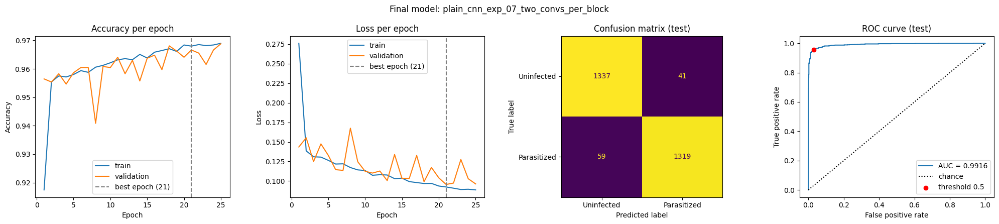

In [ ]:
# final-model figure (curves from history.json; confusion matrix + ROC from saved test predictions)
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve

h = json.loads((LOG_DIR / selected / "history.json").read_text())
best = int(np.argmin(h["val_loss"])) + 1          # 1-based, matches the epoch log
epochs = np.arange(1, len(h["loss"]) + 1)

fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))

# 1-2) Accuracy and loss curves (train vs validation, best epoch marked)
for ax, key, title in zip(axes[:2], ("accuracy", "loss"), ("Accuracy", "Loss")):
    ax.plot(epochs, h[key], label="train")
    ax.plot(epochs, h[f"val_{key}"], label="validation")
    ax.axvline(best, ls="--", c="gray", label=f"best epoch ({best})")
    ax.set(title=f"{title} per epoch", xlabel="Epoch", ylabel=title)
    ax.legend()

# 3) Confusion matrix on the test set (threshold 0.5)
cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["Uninfected", "Parasitized"]).plot(
    ax=axes[2], colorbar=False, values_format="d")
axes[2].set_title("Confusion matrix (test)")

# 4) ROC on the test set, with the 0.5-threshold operating point
fpr, tpr, _ = roc_curve(y_true, y_prob)
axes[3].plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_true, y_prob):.4f}")
axes[3].plot([0, 1], [0, 1], "k:", label="chance")
axes[3].scatter([1 - spec], [sens], c="red", zorder=3, label="threshold 0.5")
axes[3].set(title="ROC curve (test)", xlabel="False positive rate", ylabel="True positive rate")
axes[3].legend(loc="lower right")

fig.suptitle(f"Final model: {selected}")
plt.tight_layout()
fig.savefig(ROOT / "final_plots.png", dpi=200, bbox_inches="tight")
plt.show()

**What the plots show**
- **Accuracy and loss:** train and validation move together, and the best epoch is 21. Train loss is 0.092 and validation loss is 0.096 there, so there is no overfitting gap. Validation is noisy (for example a spike near epoch 8). Both curves are still improving at epoch 25, so the epoch cap may have stopped training early.
- **Confusion matrix (test):** 1,337 uninfected and 1,319 infected cells are correct. There are 41 false alarms and 59 missed infections, so misses are the more common error.
- **ROC curve (test):** AUC is 0.9916 and the curve hugs the top-left corner. The red dot is the 0.5 threshold: sensitivity 95.7%, specificity 97.0%.

### 7. Explainability: Grad-CAM
Grad-CAM shows which image regions pushed the model toward its prediction (red = most important). Three test cells: a typical correct infected cell, a typical correct uninfected cell, and the most confident missed infection. Cases are picked by a fixed rule, not by eye. Saved as `gradcam.png`.

Grad-CAM layer: block4_relu2
Correct infected (TP): test index 819, file Parasitized/C176P137NThinF_IMG_20151201_120612_cell_14.png
Correct uninfected (TN): test index 390, file Uninfected/C174P135NThinF_IMG_20151127_135554_cell_76.png
Incorrect: missed infection (FN): test index 2262, file Parasitized/C116P77ThinF_IMG_20150930_171954_cell_85.png


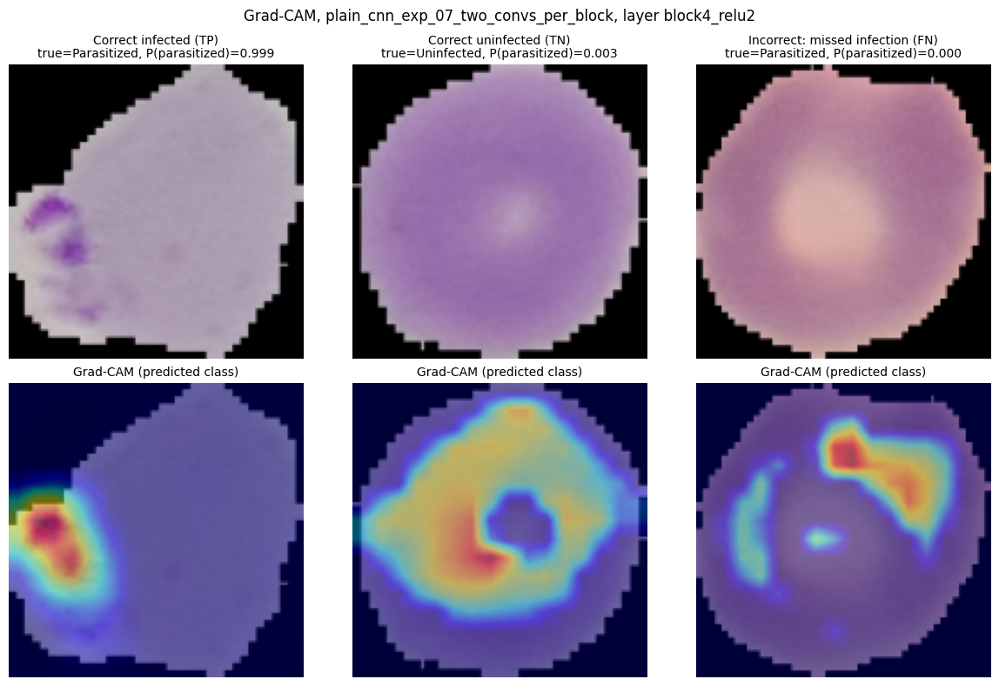

In [ ]:
# Grad-CAM on 3 test cells, target layer = last conv activation, inference mode
test_paths = [DATA_DIR / p for p in split["test"]["paths"]]
assert np.array_equal(np.array(split["test"]["labels"]), y_true), "prediction order != split order"
CAM_LAYER = last_conv_name(final_model)
print("Grad-CAM layer:", CAM_LAYER)                      # expected: block4_relu2


def load_img(path: Path) -> np.ndarray:
    """Same preprocessing as the input pipeline: decode -> resize -> [0, 1]."""
    img = tf.io.decode_png(tf.io.read_file(str(path)), channels=3)
    return (tf.image.resize(img, IMG_SIZE) / 255.0).numpy()


def gradcam(model: keras.Model, img: np.ndarray, layer_name: str) -> tuple[np.ndarray, float]:
    """Heatmap in [0, 1] (128x128) for the model's PREDICTED class, plus P(Parasitized)."""
    x = tf.convert_to_tensor(img[None])
    with tf.GradientTape() as tape:
        for layer in model.layers:                       # manual forward pass, inference mode
            x = layer(x, training=False)
            if layer.name == layer_name:
                conv = x                                 # activated last conv map (1, 16, 16, 256)
        p = x[0, 0]                                      # sigmoid output = P(Parasitized)
        score = tf.where(p >= 0.5, p, 1.0 - p)           # evidence for the predicted class
    grads = tape.gradient(score, conv)
    weights = tf.reduce_mean(grads, axis=(1, 2), keepdims=True)   # channel importance
    cam = tf.nn.relu(tf.reduce_sum(weights * conv, axis=-1))[0]   # keep positive evidence only
    cam = cam / (tf.reduce_max(cam) + 1e-8)
    return tf.image.resize(cam[..., None], IMG_SIZE).numpy().squeeze(), float(p)


# Case selection rule (fixed in code, not by eye):
#  correct cases -> median confidence = a typical example, not the prettiest one
#  incorrect case -> the most confident missed infection (FN), the clinically costly error
conf = np.abs(y_prob - 0.5)

def pick(mask: np.ndarray, most_confident: bool = False) -> int:
    idx = np.flatnonzero(mask)
    idx = idx[np.argsort(conf[idx])]                     # ascending confidence
    return int(idx[-1] if most_confident else idx[len(idx) // 2])

cases = {
    "Correct infected (TP)": pick((y_true == 1) & (y_pred == 1)),
    "Correct uninfected (TN)": pick((y_true == 0) & (y_pred == 0)),
    "Incorrect: missed infection (FN)": pick((y_true == 1) & (y_pred == 0), most_confident=True),
}

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for col, (title, i) in enumerate(cases.items()):
    img = load_img(test_paths[i])
    cam, p = gradcam(final_model, img, CAM_LAYER)
    axes[0, col].imshow(img)
    axes[0, col].set_title(f"{title}\ntrue={'Parasitized' if y_true[i] else 'Uninfected'}, "
                           f"P(parasitized)={p:.3f}", fontsize=10)
    axes[1, col].imshow(img)
    axes[1, col].imshow(cam, cmap="jet", alpha=0.45)
    axes[1, col].set_title("Grad-CAM (predicted class)", fontsize=10)
    for ax in axes[:, col]:
        ax.axis("off")
    print(f"{title}: test index {i}, file {split['test']['paths'][i]}")
fig.suptitle(f"Grad-CAM, {selected}, layer {CAM_LAYER}")
plt.tight_layout()
fig.savefig(ROOT / "gradcam.png", dpi=200, bbox_inches="tight")
plt.show()

**What we see**
- **Correct infected:** the heat sits on the purple stained parasite at the cell edge, and the rest of the cell is cold. The model looks at the right thing.
- **Correct uninfected:** the heat is spread over the cell body around the pale centre. There is no single hot spot, because there is no parasite to find.
- **Missed infection:** the cell shows no clear stain. The heat (for the predicted class, Uninfected) falls on the rim and upper right, not on a parasite. The model is confidently wrong (P = 0.000), so the parasite may be too faint, or the label may be noisy.

### 8. Error analysis
Three misclassified test cells, picked by rule: the most confident missed infection (FN), the most confident false alarm (FP) and the error closest to the 0.5 threshold. Saved as `error_analysis.png`.

Most confident FN (missed infection): test index 2262, file Parasitized/C116P77ThinF_IMG_20150930_171954_cell_85.png
Most confident FP (false alarm): test index 219, file Uninfected/C128P89ThinF_IMG_20151004_131753_cell_99.png
Borderline error (nearest 0.5): test index 1985, file Parasitized/C93P54ThinF_IMG_20150821_163640_cell_208.png


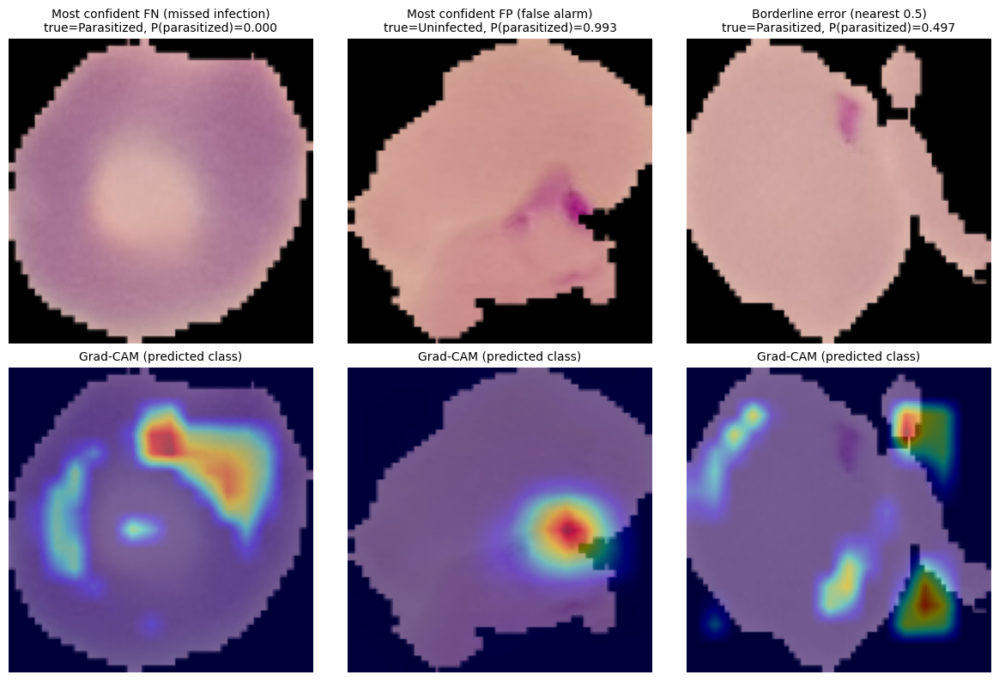

In [ ]:
# three misclassified test cells, chosen by rule (no test-set re-evaluation)
errors = np.flatnonzero(y_true != y_pred)
conf_err = np.abs(y_prob - 0.5)
fn_idx = errors[y_true[errors] == 1]
fp_idx = errors[y_true[errors] == 0]
err_cases = {
    "Most confident FN (missed infection)": int(fn_idx[np.argmax(conf_err[fn_idx])]),
    "Most confident FP (false alarm)": int(fp_idx[np.argmax(conf_err[fp_idx])]),
    "Borderline error (nearest 0.5)": int(errors[np.argmin(conf_err[errors])]),
}

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for col, (title, i) in enumerate(err_cases.items()):
    img = load_img(test_paths[i])
    cam, p = gradcam(final_model, img, CAM_LAYER)
    axes[0, col].imshow(img)
    axes[0, col].set_title(f"{title}\ntrue={'Parasitized' if y_true[i] else 'Uninfected'}, "
                           f"P(parasitized)={p:.3f}", fontsize=10)
    axes[1, col].imshow(img)
    axes[1, col].imshow(cam, cmap="jet", alpha=0.45)
    axes[1, col].set_title("Grad-CAM (predicted class)", fontsize=10)
    for ax in axes[:, col]:
        ax.axis("off")
    print(f"{title}: test index {i}, file {split['test']['paths'][i]}")
plt.tight_layout()
fig.savefig(ROOT / "error_analysis.png", dpi=200, bbox_inches="tight")
plt.show()

**What we see**
- **Most confident FN (P = 0.000):** a smooth cell with no visible stain. The parasite is probably too faint, or the label is wrong.
- **Most confident FP (P = 0.993):** an irregular, folded cell with a dark pink fold. The heat is one spot on that fold, so a stain-like fold looks like a parasite to the model.
- **Borderline FN (P = 0.497):** a pale cell with one small purple spot. The evidence is weak and just under the threshold. The heat is spread out and partly on the cell edge next to the dark background.

**Common thread:** errors come from faint parasites, stain-like artefacts and odd cell shapes.

### Summary of results
- **Final model:** exp 07 (2 convs per block, BatchNorm, flips + ±36° rotation, Flatten head), 3,272,545 parameters.
- **Test result:** accuracy 96.4%, sensitivity 95.7% (95% CI 94.5–96.7), specificity 97.0% (96.0–97.8), AUC 0.992. Both targets (≥ 90%) are met, including at the CI lower bounds.
- **What helped:** augmentation (val_loss 0.119 → 0.102 and the train/val gap closed). Deeper blocks gave the lowest val_loss (0.0955) but are tied with exp 03 within noise.
- **What did not help:** BatchNorm (tie), dropout, lower learning rate, and the GAP head (worse).
- **Errors:** 59 missed infections and 41 false alarms out of 2,756 test cells.

### 9. Package the logs
Zip the raw TensorBoard logs for the report appendix (share the Drive link).

In [ ]:
# zip model4/logs for the appendix (raw TensorBoard logs)
shutil.make_archive(str(ROOT / "model4_logs"), "zip", LOG_DIR)
print(ROOT / "model4_logs.zip")

/content/drive/MyDrive/ml-formative-2/model4/model4_logs.zip


### Limitations
- **Image-level split:** the dataset has patient IDs in the filenames, but the shared split is stratified by image, so images from the same patient can appear in train, validation and test. Test performance may therefore be optimistic compared with unseen patients.
- **Single seed (42):** each configuration was run once. Re-runs moved val_loss by up to 0.011 and sensitivity/specificity by up to about 2 pp (see the noise caveat), so small gaps between experiments are not conclusive.
- **Shared 25-epoch budget:** every run had the same cap for fairness. Exp 07 reached its best epoch at 21, so the cap may have limited it.
- **Validation-based selection:** the final model was chosen on validation data; the test set is evaluated once.